In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad
import tracemalloc
import time

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem domain and parameters
L = 5.0
beta = 3e5

def u_exact_func(x):
    return np.sin(np.pi * x) / (np.pi**2 + 1)

#############################
# --- RBF solver ---
#############################

def run_rbf_solver(
    N,
    L=5.0,
    Amplitude=50.0,
    beta=3e5,
    tau=1e-15,
    c_shape=0.134,
    zeta=2,
    T_cent=1.0,
    use_trapezoid_weights=True,   # True = your script; False = uniform dx like the other solver
    penalty_prefactor=1.0,        # 1.0 = this script; 2.0 = earlier TSVD variant
    use_sqrtN_rep=True,          
    jitter=False,
    jitter_scale=1e-6,
):
    """
    Variational Gaussian-RBF TSVD solver for -u'' + u = A sin(pi x), u(0)=u(L)=0
    Returns (rel_L2_error_squared, peak_mem_MB, runtime_s)
    """
    import numpy as np
    import tracemalloc, time
    from scipy.spatial.distance import cdist
    from numpy.linalg import svd

    # --- helpers ---
    def gaussian_rbf(r, eps):
        return np.exp(-(eps * r) ** 2)

    def d_gaussian_rbf(r, eps):
        return -2.0 * eps**2 * r * np.exp(-(eps * r) ** 2)

    def assemble_basis(x_eval, centers, eps, deriv=0):
        r = cdist(x_eval[:, None], centers[:, None])
        if deriv == 0:
            return gaussian_rbf(r, eps)
        diff = x_eval[:, None] - centers[None, :]
        return d_gaussian_rbf(np.abs(diff), eps) * np.sign(diff)

    def u_true(A, x):
        return A * np.sin(np.pi * x) / (1.0 + np.pi**2)

    # --- centers & grids ---
    a, b = 0.0, L
    Lh = 0.5 * (b - a); q = 0.5 * (a + b)
    centers = np.linspace(q - T_cent * Lh, q + T_cent * Lh, N)
    if jitter:
        centers += np.random.normal(0.0, jitter_scale, size=N)
        centers = np.clip(centers, q - T_cent * Lh, q + T_cent * Lh)

    M = max(4, int(zeta * N))
    x_int = np.linspace(a, b, M)
    dx = (b - a) / (M - 1)

    # shape parameter
    eps = c_shape * N

    # basis
    Phi   = assemble_basis(x_int, centers, eps, deriv=0)
    Phi_x = assemble_basis(x_int, centers, eps, deriv=1)

    # weights
    if use_trapezoid_weights:
        wts = np.ones(M); wts[0] = wts[-1] = 0.5
        Wcol = (wts * dx)[:, None]
        A_core = Phi_x.T @ (Wcol * Phi_x) + Phi.T @ (Wcol * Phi)
        b_core = Phi.T @ ((wts * dx) * (Amplitude * np.sin(np.pi * x_int)))
    else:
        A_core = dx * (Phi_x.T @ Phi_x + Phi.T @ Phi)
        b_core = dx * (Phi.T @ (Amplitude * np.sin(np.pi * x_int)))

    # penalty
    P0 = gaussian_rbf(np.abs(centers - a), eps)
    PL = gaussian_rbf(np.abs(centers - b), eps)
    A_pen = penalty_prefactor * beta * (np.outer(P0, P0) + np.outer(PL, PL))

    # system matrix and RHS before (optional) sqrtN scaling
    A = A_core + A_pen
    b_vec = b_core.copy()

    # optional 1/sqrt(N) representation:
    # scaled formulation leads to A_unscaled w = sqrt(N) * b_unscaled (see earlier derivation)
    rhs = (np.sqrt(N) * b_vec) if use_sqrtN_rep else b_vec

    # --- TSVD solve ---
    tracemalloc.start()
    t0 = time.perf_counter()

    U, s, Vt = svd(A, full_matrices=False)
    cutoff = tau * s[0]
    mask = s > cutoff
    inv_s = np.zeros_like(s); inv_s[mask] = 1.0 / s[mask]
    w_tsvd = (Vt.T * inv_s) @ (U.T @ rhs)

    runtime = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # --- evaluate on the same grid ---
    Phi_plot = Phi  # reuse
    if use_sqrtN_rep:
        u_num = (1.0 / np.sqrt(N)) * (Phi_plot @ w_tsvd)
    else:
        u_num = Phi_plot @ w_tsvd

    u_ex = u_true(Amplitude, x_int)

    # relative L2 (squared) using the same grid & weights as the assembly choice
    if use_trapezoid_weights:
        err2 = np.sum(((u_num - u_ex)**2) * (wts * dx))
        ref2 = np.sum((u_ex**2) * (wts * dx))
    else:
        err2 = dx * np.sum((u_num - u_ex)**2)
        ref2 = dx * np.sum(u_ex**2)

    rel_L2_sq = err2 / max(ref2, 1e-300)



    
    return rel_L2_sq, peak / (1024 * 1024), runtime




#############################
# --- Finite Difference Solver ---
#############################

def run_fd_solver(N):
    from scipy.optimize import minimize

    def energy_and_grad_fd(u_interior, x, f):
        dx = x[1] - x[0]
        u_full = np.zeros(N+2)
        u_full[1:-1] = u_interior

        du_dx = (u_full[2:] - u_full[:-2]) / (2*dx)
        J = 0.5 * np.sum(du_dx**2 + u_full[1:-1]**2) * dx - np.sum(f[1:-1] * u_full[1:-1]) * dx

        grad = np.zeros(N)
        for i in range(N):
            u_i = u_full[i+1]
            u_im1 = u_full[i] if i > 0 else 0.0
            u_ip1 = u_full[i+2] if i < N-1 else 0.0
            laplacian = (u_im1 - 2*u_i + u_ip1) / dx**2
            grad[i] = (-laplacian + u_i - f[i+1]) * dx
        return J, grad

    def wrapper(u_interior, x, f):
        return energy_and_grad_fd(u_interior, x, f)

    x = np.linspace(0, L, N+2)
    f = np.sin(np.pi * x)
    u0 = np.zeros(N)

    tracemalloc.start()
    start_time = time.perf_counter()
    res = minimize(wrapper, u0, args=(x, f), method='L-BFGS-B', jac=True, options={'disp': False})
    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time

    u_opt = res.x
    u_full = np.zeros(N+2)
    u_full[1:-1] = u_opt

    u_ex = u_exact_func(x)
    error_l2 = np.sqrt(np.trapz((u_full - u_ex)**2, x))
    norm_exact_l2 = np.sqrt(np.trapz(u_ex**2, x))



    
    return error_l2 / norm_exact_l2, peak / (1024*1024), runtime





#############################
# --- Neural Network Solver ---
#############################

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.net(x)

def compute_energy(model, x, f, beta):
    x.requires_grad_(True)
    u = model(x)
    du_dx = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    energy_density = 0.5 * du_dx**2 + 0.5 * u**2 - f * u
    J = torch.mean(energy_density)

    u0 = model(torch.tensor([[0.0]], dtype=torch.float32, device=device))
    uL = model(torch.tensor([[L]], dtype=torch.float32, device=device))
    J += beta * ((u0**2).sum() + (uL**2).sum())
    return J

def run_nn_solver(N):
    x_np = np.linspace(0, L, N).reshape(-1,1)
    x = torch.tensor(x_np, dtype=torch.float32, device=device)
    f = torch.sin(np.pi * x).to(device)

    model = Net().to(device)

    optimizer = torch.optim.LBFGS(model.parameters(), max_iter=1000, tolerance_grad=1e-6)

    tracemalloc.start()
    start_time = time.perf_counter()

    def closure():
        optimizer.zero_grad()
        loss = compute_energy(model, x, f, beta)
        loss.backward()
        return loss

    optimizer.step(closure)

    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time

    x_test = np.linspace(0, L, 1000).reshape(-1,1)
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)
    u_nn = model(x_test_tensor).detach().cpu().numpy().flatten()
    u_exact = u_exact_func(x_test.flatten())

    error_l2 = np.trapz((u_nn - u_exact)**2, x_test.flatten())
    norm_exact_l2 = np.trapz(u_exact**2, x_test.flatten())
    return error_l2 / norm_exact_l2, peak / (1024*1024), runtime

## Galerkin method
def run_galerkin_solver(N, L=1.0):
    """
    P1 FEM Galerkin for:  -u''(x) + u(x) = sin(pi x)  on [0, L],  u(0)=u(L)=0
    N = number of interior nodes (so elements = N+1).
    Returns: (rel_L2_error, peak_mem_MB, runtime_s)
    """
    import numpy as np, time, tracemalloc
    pi = np.pi

    # Exact solution (for L=1, the sinh term vanishes)
    def u_exact(x):
        if abs(np.sin(pi * L)) < 1e-14:
            return np.sin(pi * x) / (pi**2 + 1.0)
        return (np.sin(pi * x) / (pi**2 + 1.0)
                - (np.sin(pi * L) / (pi**2 + 1.0)) * np.sinh(x) / np.sinh(L))

    # Mesh
    h = L / (N + 1)
    x = np.linspace(0.0, L, N + 2)

    # Assembled tridiagonal K and M (Dirichlet BCs eliminated)
    # K: diag=2/h, off=-1/h
    mainK = (2.0 / h) * np.ones(N)
    offK  = (-1.0 / h) * np.ones(N - 1)
    # M (consistent): diag=2h/3, off=h/6   <-- FIXED
    mainM = (2.0 * h / 3.0) * np.ones(N)
    offM  = (h / 6.0) * np.ones(N - 1)

    mainA = mainK + mainM
    offA  = offK  + offM

    # Load vector: F_i = ∫ f φ_i dx, accurate element quadrature (2-pt Gauss is enough)
    def f(x): return np.sin(pi * x)
    b_vec = np.zeros(N)
    gp = np.array([-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)])
    gw = np.array([1.0, 1.0])

    for e in range(N + 1):
        xL = x[e]
        hloc = x[e + 1] - x[e]
        fe = np.zeros(2)
        for xi_k, w_k in zip(gp, gw):
            t = 0.5 * (xi_k + 1.0)     # map [-1,1] -> [0,1]
            xx = xL + t * hloc
            phiL = 1.0 - t
            phiR = t
            fe[0] += w_k * f(xx) * phiL * (hloc / 2.0)
            fe[1] += w_k * f(xx) * phiR * (hloc / 2.0)
        if e > 0:
            b_vec[e - 1] += fe[0]
        if e < N:
            b_vec[e]     += fe[1]

    # Solve tridiagonal (Thomas)
    tracemalloc.start()
    t0 = time.perf_counter()

    a = offA.copy()   # sub
    b = mainA.copy()  # diag
    c = offA.copy()   # super
    d = b_vec.copy()  # rhs

    for i in range(1, N):
        m = a[i - 1] / b[i - 1]
        b[i] -= m * c[i - 1]
        d[i] -= m * d[i - 1]

    u_int = np.zeros(N)
    u_int[-1] = d[-1] / b[-1]
    for i in range(N - 2, -1, -1):
        u_int[i] = (d[i] - c[i] * u_int[i + 1]) / b[i]

    t1 = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Full solution and L2 error
    u_full = np.zeros(N + 2)
    u_full[1:-1] = u_int
    u_ex = u_exact(x)

    rel_L2 = (np.sqrt(np.trapz((u_full - u_ex)**2, x))
              / np.sqrt(np.trapz(u_ex**2, x)))

    runtime = t1 - t0
    peak_MB = peak / (1024.0 * 1024.0)
    return rel_L2, peak_MB, runtime




## Spectral method
def run_spectral_solver(N):
    """
    Chebyshev collocation for -u'' + u = sin(pi x) on [0, L], u(0)=u(L)=0.
    Returns (rel_L2_error, peak_mem_MB, runtime_s).
    Uses global L and u_exact_func.
    """
    import numpy as np
    import tracemalloc, time

    # Chebyshev nodes on [-1,1] → map to [0, L] (NOTICE: descending order!)
    xi = np.cos(np.pi * np.arange(N + 1) / N)
    x  = 0.5 * L * (xi + 1.0)

    # Chebyshev differentiation matrix on [-1,1]
    c = np.ones(N + 1); c[0] = c[-1] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X  = np.tile(xi, (N + 1, 1))
    dX = X - X.T + np.eye(N + 1)
    Dxi = np.outer(c, 1.0 / c) / dX
    Dxi = Dxi - np.diag(np.sum(Dxi, axis=1))

    # Rescale to [0, L]
    D  = (2.0 / L) * Dxi
    D2 = D @ D

    i = slice(1, -1)
    A_in = -D2[i, i] + np.eye(N - 1)
    f    = np.sin(np.pi * x)
    rhs  = f[1:-1]  # u(0)=u(L)=0

    tracemalloc.start()
    t0 = time.perf_counter()
    u_interior = np.linalg.solve(A_in, rhs)
    runtime = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    u_pred = np.zeros(N + 1)
    u_pred[1:-1] = u_interior

    # ---- Robust relative L2 on [0, L]: sort x ascending before trapz ----
    u_ex = u_exact_func(x)
    idx = np.argsort(x)
    xs   = x[idx]
    e2   = (u_pred[idx] - u_ex[idx])**2
    ref2 = (u_ex[idx])**2

    num = np.trapz(e2, xs)
    den = np.trapz(ref2, xs)
    # Guard tiny negative due to fp error
    num = abs(num)
    den = abs(den)
    rel_L2 = 0.0 if den == 0.0 else (np.sqrt(num) / np.sqrt(den))

    return rel_L2, peak / (1024 * 1024), runtime



In [2]:
#############################
# --- Run benchmark ---
#############################

#Ns = [100, 200, 400, 800, 1600, 3200, 6400, 12800]
Ns = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
errors_rbf = []
errors_fd = []
errors_nn = []

errors_gal, mem_gal, times_gal = [], [], []
#errors_spectral, mem_spec, times_spec = [], [], []

mem_rbf = []
mem_fd = []
mem_nn = []

times_rbf = []
times_fd = []
times_nn = []

print("Running RBF solver:")
for N in Ns:
    err, mem, t = run_rbf_solver(N)
    print(f"N={N} RBF Relative L2 error = {err:.4e}, Peak memory = {mem:.2f} MB, Time = {t:.2f} s")
    errors_rbf.append(err)
    mem_rbf.append(mem)
    times_rbf.append(t)

print("\nRunning FD solver:")
for N in Ns:
    err, mem, t = run_fd_solver(N)
    print(f"N={N} FD Relative L2 error = {err:.4e}, Peak memory = {mem:.2f} MB, Time = {t:.2f} s")
    errors_fd.append(err)
    mem_fd.append(mem)
    times_fd.append(t)

print("\nRunning NN solver:")
for N in Ns:
    err, mem, t = run_nn_solver(N)
    print(f"N={N} NN Relative L2 error = {err:.4e}, Peak memory = {mem:.2f} MB, Time = {t:.2f} s")
    errors_nn.append(err)
    mem_nn.append(mem)
    times_nn.append(t)



print("\nRunning Galerkin solver:")
for N in Ns:
    err, mem, t = run_galerkin_solver(N)
    print(f"N={N} Galerkin Relative L2 error = {err:.4e}, Peak memory = {mem:.2f} MB, Time = {t:.3f} s")
    errors_gal.append(err); mem_gal.append(mem); times_gal.append(t)

#print("\nRunning Spectral (Chebyshev) solver:")
#for N in Ns:
#    err, mem, t = run_spectral_solver(N)
#    print(f"N={N} Spectral Relative L2 error = {err:.4e}, Peak memory = {mem:.2f} MB, Time = {t:.3f} s")
#    errors_spectral.append(err); mem_spec.append(mem); times_spec.append(t)


Running RBF solver:
N=8 RBF Relative L2 error = 7.0348e-03, Peak memory = 0.00 MB, Time = 0.00 s
N=16 RBF Relative L2 error = 4.0470e-04, Peak memory = 0.01 MB, Time = 0.00 s
N=32 RBF Relative L2 error = 5.2555e-05, Peak memory = 0.03 MB, Time = 0.00 s
N=64 RBF Relative L2 error = 9.3867e-06, Peak memory = 0.13 MB, Time = 0.00 s
N=128 RBF Relative L2 error = 1.9764e-06, Peak memory = 0.44 MB, Time = 0.00 s
N=256 RBF Relative L2 error = 4.5625e-07, Peak memory = 1.57 MB, Time = 0.03 s
N=512 RBF Relative L2 error = 1.1130e-07, Peak memory = 6.07 MB, Time = 0.17 s
N=1024 RBF Relative L2 error = 2.8348e-08, Peak memory = 24.08 MB, Time = 1.05 s
N=2048 RBF Relative L2 error = 7.5935e-09, Peak memory = 96.10 MB, Time = 7.68 s

Running FD solver:
N=8 FD Relative L2 error = 2.6314e-01, Peak memory = 0.02 MB, Time = 0.00 s
N=16 FD Relative L2 error = 4.2974e-01, Peak memory = 0.02 MB, Time = 0.03 s
N=32 FD Relative L2 error = 1.3288e-01, Peak memory = 0.03 MB, Time = 0.05 s
N=64 FD Relative L2 

/opt/module-jupyter-gpu/2.0-cuda-11-8/lib/python3.11/site-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


N=8 NN Relative L2 error = 1.0103e+00, Peak memory = 0.08 MB, Time = 0.38 s
N=16 NN Relative L2 error = 1.2519e+00, Peak memory = 0.01 MB, Time = 0.06 s
N=32 NN Relative L2 error = 1.5426e+00, Peak memory = 0.01 MB, Time = 0.10 s
N=64 NN Relative L2 error = 1.1150e+00, Peak memory = 0.01 MB, Time = 0.10 s
N=128 NN Relative L2 error = 1.4060e+00, Peak memory = 0.01 MB, Time = 0.15 s
N=256 NN Relative L2 error = 1.7142e+00, Peak memory = 0.01 MB, Time = 0.10 s
N=512 NN Relative L2 error = 9.8679e-01, Peak memory = 0.01 MB, Time = 0.08 s
N=1024 NN Relative L2 error = 1.5483e+00, Peak memory = 0.01 MB, Time = 0.09 s
N=2048 NN Relative L2 error = 9.6817e-01, Peak memory = 0.01 MB, Time = 0.10 s

Running Galerkin solver:
N=8 Galerkin Relative L2 error = 9.3969e-04, Peak memory = 0.00 MB, Time = 0.001 s
N=16 Galerkin Relative L2 error = 2.6225e-04, Peak memory = 0.00 MB, Time = 0.003 s
N=32 Galerkin Relative L2 error = 6.9513e-05, Peak memory = 0.00 MB, Time = 0.004 s
N=64 Galerkin Relative L

In [3]:
# =========================
# Helper: convergence order
# =========================
def local_orders(Ns, errs):
    Ns = np.asarray(Ns, dtype=float)
    errs = np.asarray(errs, dtype=float)
    # keep only strictly positive finite errors
    mask = np.isfinite(errs) & (errs > 0)
    Ns = Ns[mask]
    errs = errs[mask]
    if len(Ns) < 2:
        return Ns, np.array([]), np.nan
    # p_i between successive pairs
    p = -np.log(errs[1:] / errs[:-1]) / np.log(Ns[1:] / Ns[:-1])
    p_bar = np.mean(p)
    return Ns[1:], p, p_bar
# Ensure Ns is a numpy array for element-wise operations
Ns = np.array(Ns)

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

# Ensure output dir exists
outdir = "./Outputs/1D_ReactionDiffusion"
os.makedirs(outdir, exist_ok=True)


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})

# =========================
# Fig 1: Convergence vs N
# =========================
plt.figure(figsize=(9, 7), dpi = 300)
plt.plot(Ns, errors_rbf,'o-', label='RBF', linewidth=4.5)
plt.plot(Ns, errors_gal, 's--', label='Galerkin', linewidth=4.5)
plt.plot(Ns,  errors_nn, 'd-.', label='NN', linewidth=4.5)
#plt.plot(Ns, errors_spectral,'x-', label='Spectral', linewidth=4.5)
plt.plot(Ns, errors_fd, '>-.', label='Finite-Difference', linewidth=4.5)


plt.xscale('log', base = 2)
plt.yscale('log')
plt.xlabel(r'$N$: number of basis functions', fontsize=16)
plt.ylabel(r'Relative $L^2$ Error', fontsize=16)
plt.title('Error vs. N', fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.grid(True)
plt.legend(loc='upper center', title = 'Method(s)',title_fontsize = 18, fontsize=16, frameon=True, bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'fig2_reactiondiffusion_convergence.png'), dpi=300)
plt.close()

# =========================
# Fig 2: Local estimated convergence order p_i
# =========================
series = {
    'RBF':           errors_rbf,
    'Galerkin':      errors_gal,
    'NN':            errors_nn,
   # 'Spectral':      errors_spectral,
    'Finite-Diff.':  errors_fd
}

marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 7.5))
legend_labels = []
for name, errs in series.items():
    Nx, p_i, p_bar = local_orders(Ns, errs)
    if p_i.size == 0:
        continue
    plt.plot(Nx, p_i,marker=next(marker_cycle), linestyle=next(linestyle_cycle), linewidth=4.5, label=fr"{name}, ( p = {p_bar:.1f})")
plt.xscale('log', base=2)  # since N often doubles
plt.xlabel(r'$N$: number of basis functions', fontsize=20)
plt.ylabel(r'Local order $p_i$', fontsize=20)
plt.title('Estimated convergence order in Reaction-Diffusion PDE', fontsize=20)
plt.tick_params(labelsize=20)
plt.grid(True)
plt.legend(loc='best', fontsize=18, frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'fig2_local_convergence_order.png'), dpi=300)
plt.close()


# 20 Independent runs

In [5]:
# Jitter RBF Boxplot Experiments# ----------------------------
#max_runs = 20
#Ns_jitter = [100, 500, 1000, 2000]
#jitter_results = {N: [] for N in Ns_jitter}

#for N in Ns_jitter:
#    for _ in range(max_runs):
#        err, _, _ = run_rbf_solver(N, jitter = True, jitter_scale = 1e-5)
#        jitter_results[N].append(err)

In [6]:
import pandas as pd
import seaborn as sns 
# =========================
# Fig 2: Run-to-run spread
# =========================
# Build violin DataFrame (expects Ns_jitter, jitter_results to be defined)
#violin_data = []
#for N in Ns_jitter:
#    for val in jitter_results[N]:
#        violin_data.append({'N': N, 'Error': val})
#df_violin = pd.DataFrame(violin_data)

#plt.figure(figsize=(9, 7))
#sns.violinplot(
#    data=df_violin,
#    x='N', y='Error',
#    palette="Set2",   # you can remove palette if you prefer defaults
#    inner="box",
#    scale="area",
#    width=1.0,
#    linewidth=2.0
#)

# y-limits with padding
#ymin = df_violin['Error'].min()
#ymax = df_violin['Error'].max()
#plt.ylim(ymin * 0.2, ymax * 1.8)

#plt.yscale('log')
#plt.xlabel(r'$N$: number of basis functions', fontsize=20)
#plt.ylabel(r'Relative $L^2$ Error', fontsize=16)
#plt.title(f'Experiment in {max_runs:2d} runs', fontsize=20)
#plt.tick_params(labelsize=20)
#plt.minorticks_on()
#plt.grid(True, axis='y')  # grid on y is most readable for violins
#plt.tight_layout()
#plt.savefig(os.path.join(outdir, 'fig2_reactiondiffusion_run.png'), dpi=300)
#plt.close()

# Experiment with variation of T


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_values = np.array([1.0, 1.5, 2.0, 4.0, 6.0], dtype=float)   # trim if you want fewer lines
tau = 1e-15



# Helper: compute c(T) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by (T, c) -> arrays
E = {}        # (T, c) -> array of rel L2 error vs N

# Precompute c values aligned with T_values
c_values = np.array([c_from_T(T_val, tau) for T_val in T_values], dtype=float)

# Optional: print a quick table of T and c
print("T and c values used:")
for T_val, c_val in zip(T_values, c_values):
    print(f"  T={T_val:>3.1f}  c={c_val:.6e}")

for (T_val, c_val) in zip(T_values, c_values):
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        if (T_val >= 2.5):
            rel_l2_err, _, _ = run_rbf_solver(N, c_shape = c_val, T_cent = T_val)
        else: 
            rel_l2_err, _, _ = run_rbf_solver(N, c_shape = c_val)
        errs.append(float(rel_l2_err))
        
    key = (float(T_val), float(c_val))
    E[key] = np.asarray(errs, dtype=float)
   

# =======================
# Optional sanity checks (overlay detection across different T,c)
# =======================
if len(T_values) >= 2:
    # Compare to the first pair
    base_key = (float(T_values[0]), float(c_values[0]))
    base_E = E[base_key]
    for i in range(1, len(T_values)):
        other_key = (float(T_values[i]), float(c_values[i]))
        if np.allclose(base_E, E[other_key], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for T={base_key[0]:g}, c={base_key[1]:.3e} "
                  f"and T={other_key[0]:g}, c={other_key[1]:.3f} are numerically identical.")



T and c values used:
  T=1.0  c=2.672800e-01
  T=1.5  c=1.781866e-01
  T=2.0  c=1.336400e-01
  T=4.0  c=6.681999e-02
  T=6.0  c=4.454666e-02


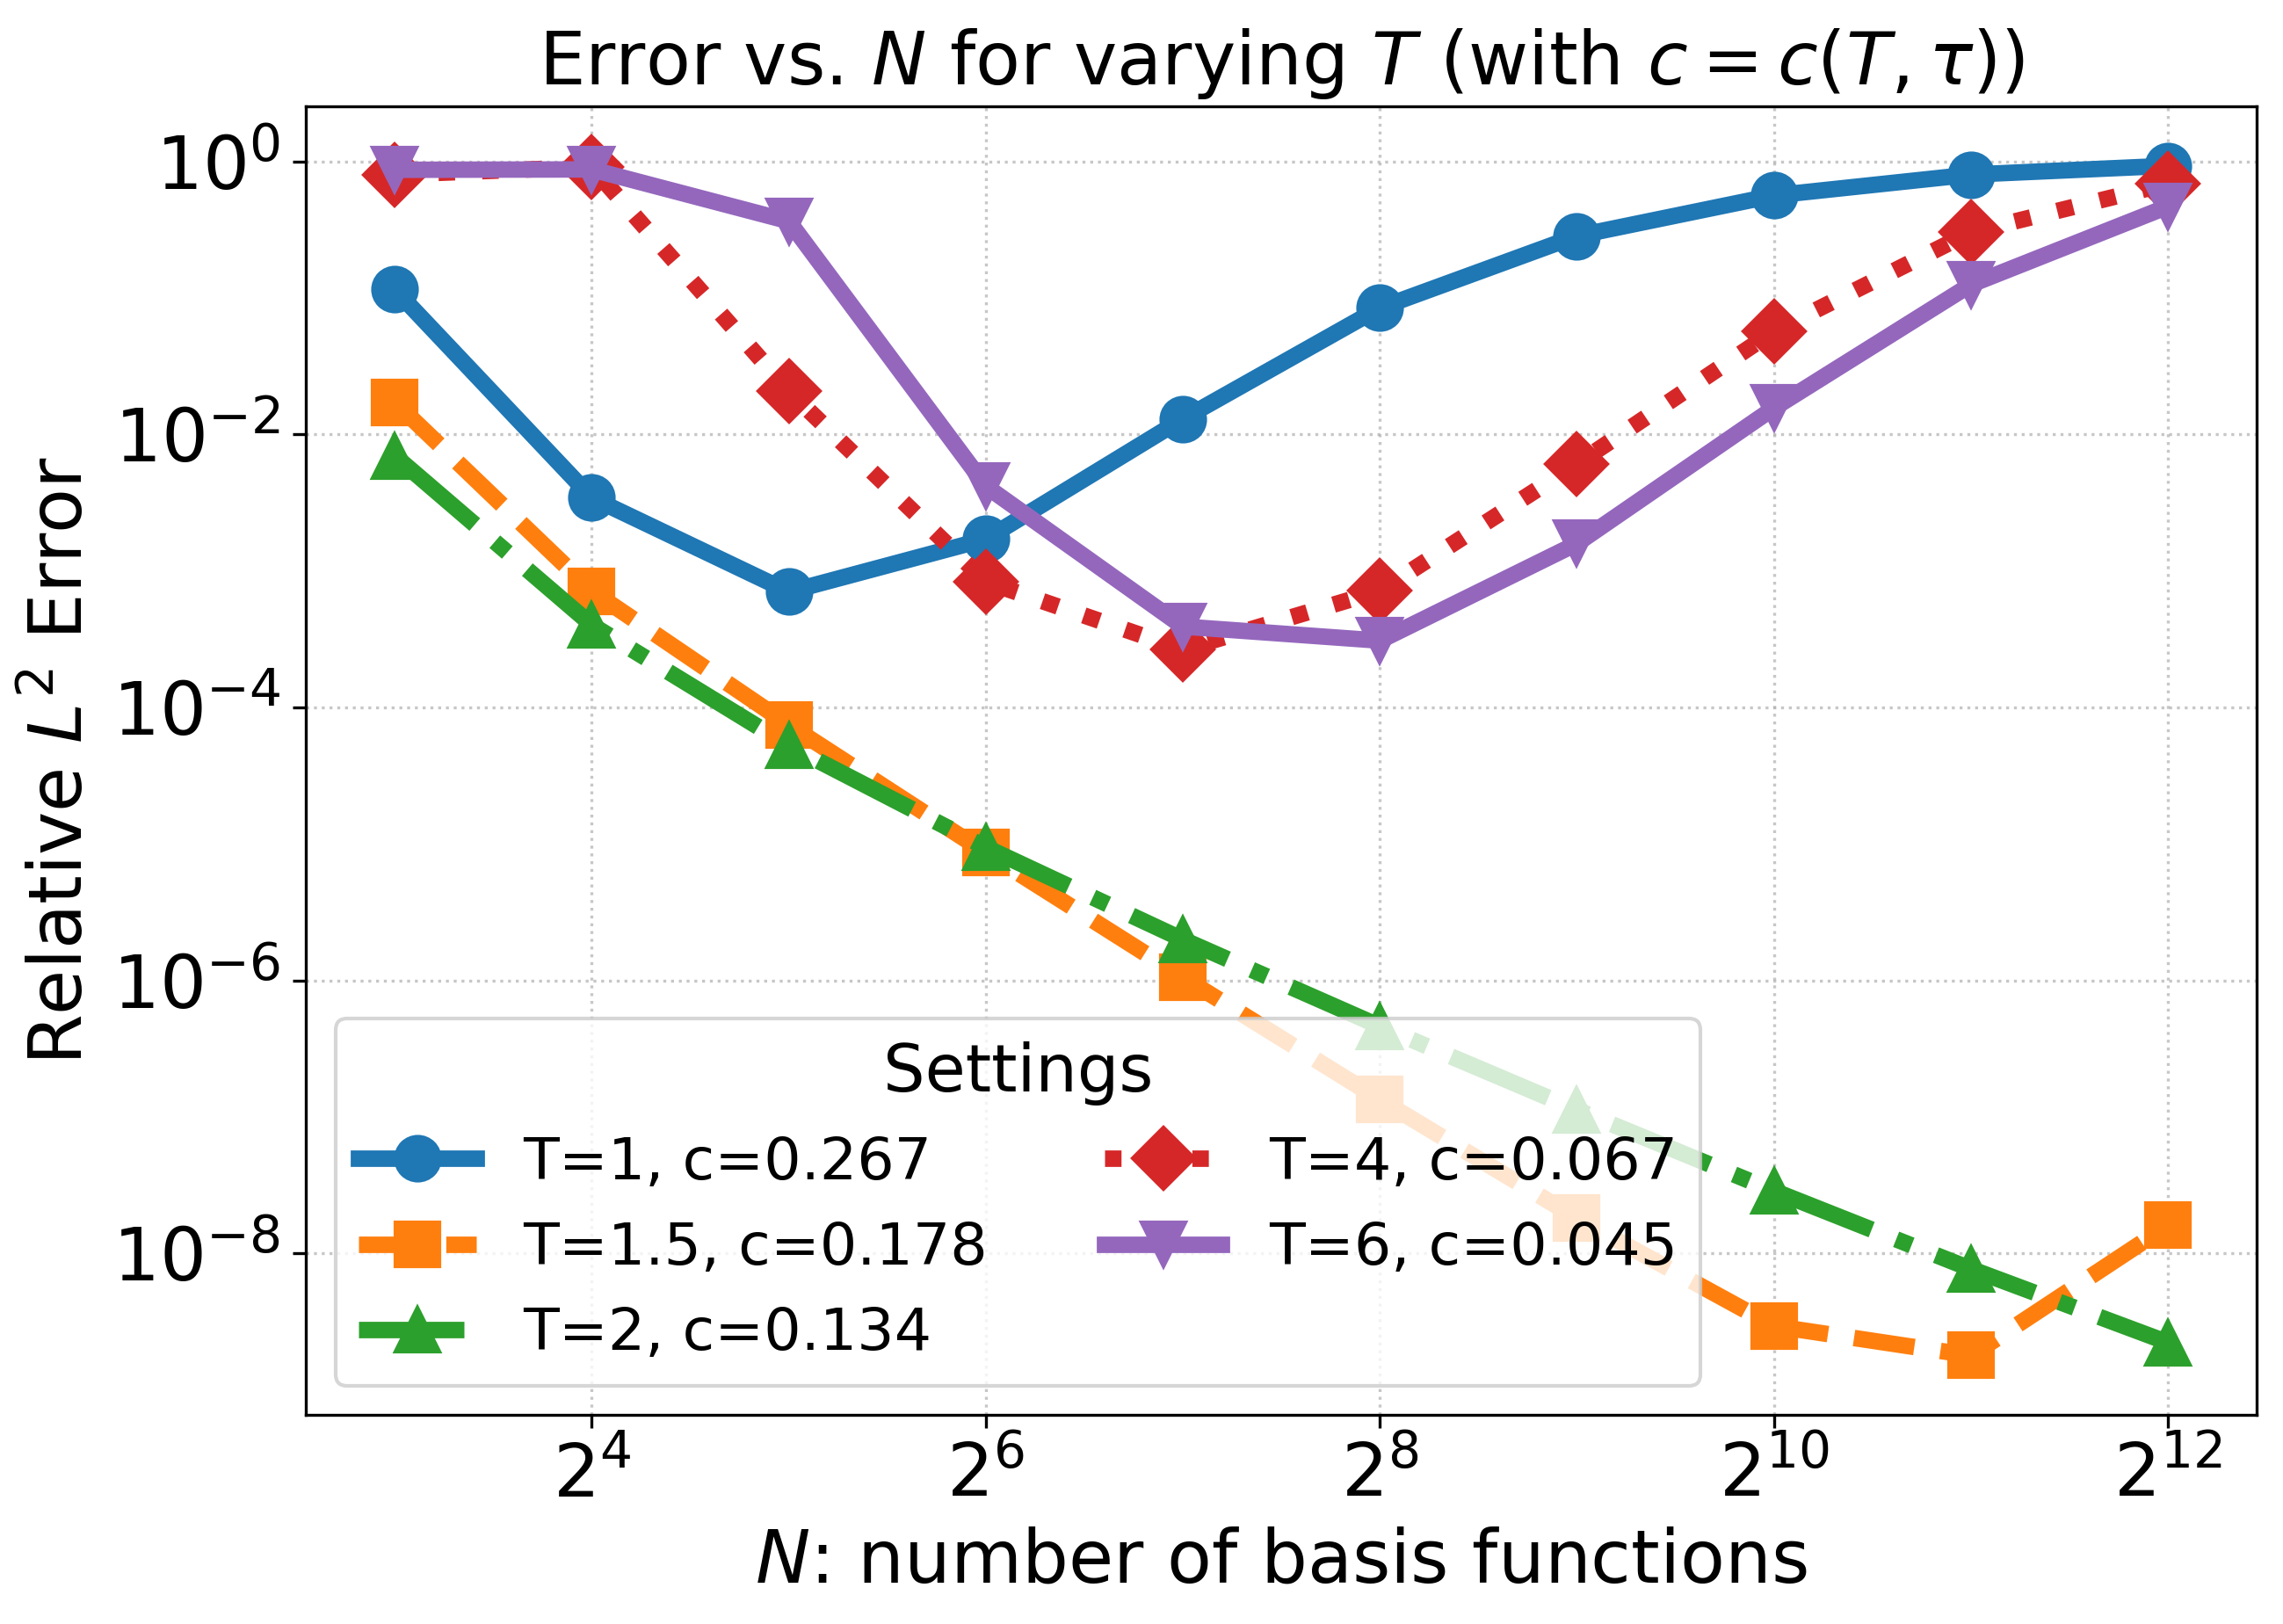

In [6]:
# =======================
# Plot E(N) vs N for each (T, c)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])
legend_fontsize = 16
plt.figure(figsize=(9, 6.5), dpi=300)
# Sort by T for a consistent legend order
for (T_val, c_val) in sorted(E.keys(), key=lambda t: t[0]):
    y = E[(T_val, c_val)]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=4.5,
        markersize=12,
        label=f"T={T_val:g}, c={c_val:.3f}"
    )

# If you prefer log-x since N doubles, uncomment:
plt.xscale('log', base=2)
plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(r"Error vs. $N$ for varying $T$ (with $c=c(T,\tau)$)", fontsize=20)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.legend(title="Settings", fontsize=legend_fontsize, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig3_reactiondiffusion.png')
#plt.show()

# We fix $T$ and vary $c$ 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 3.5,
    "lines.markersize": 16,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary c
T_fixed = 1.5
tau_val = 1e-10



# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_val)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.09820493, 0.13093991, 0.16367488, 0.19640986, 0.24551232, 0.29461479, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err, _, _ = run_rbf_solver(N, c_shape = c_val, T_cent = T_fixed, tau = tau_val)
        errs.append(float(rel_l2_err))

    E[float(c_val)] = np.asarray(errs, dtype=float)


# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.1e} and c={c_val:.2f} are numerically identical.")

Fixed T = 1.5
c values used:
  c=9.820493e-02
  c=1.309399e-01
  c=1.636749e-01
  c=1.964099e-01
  c=2.455123e-01
  c=2.946148e-01
  c=2.182332e-01


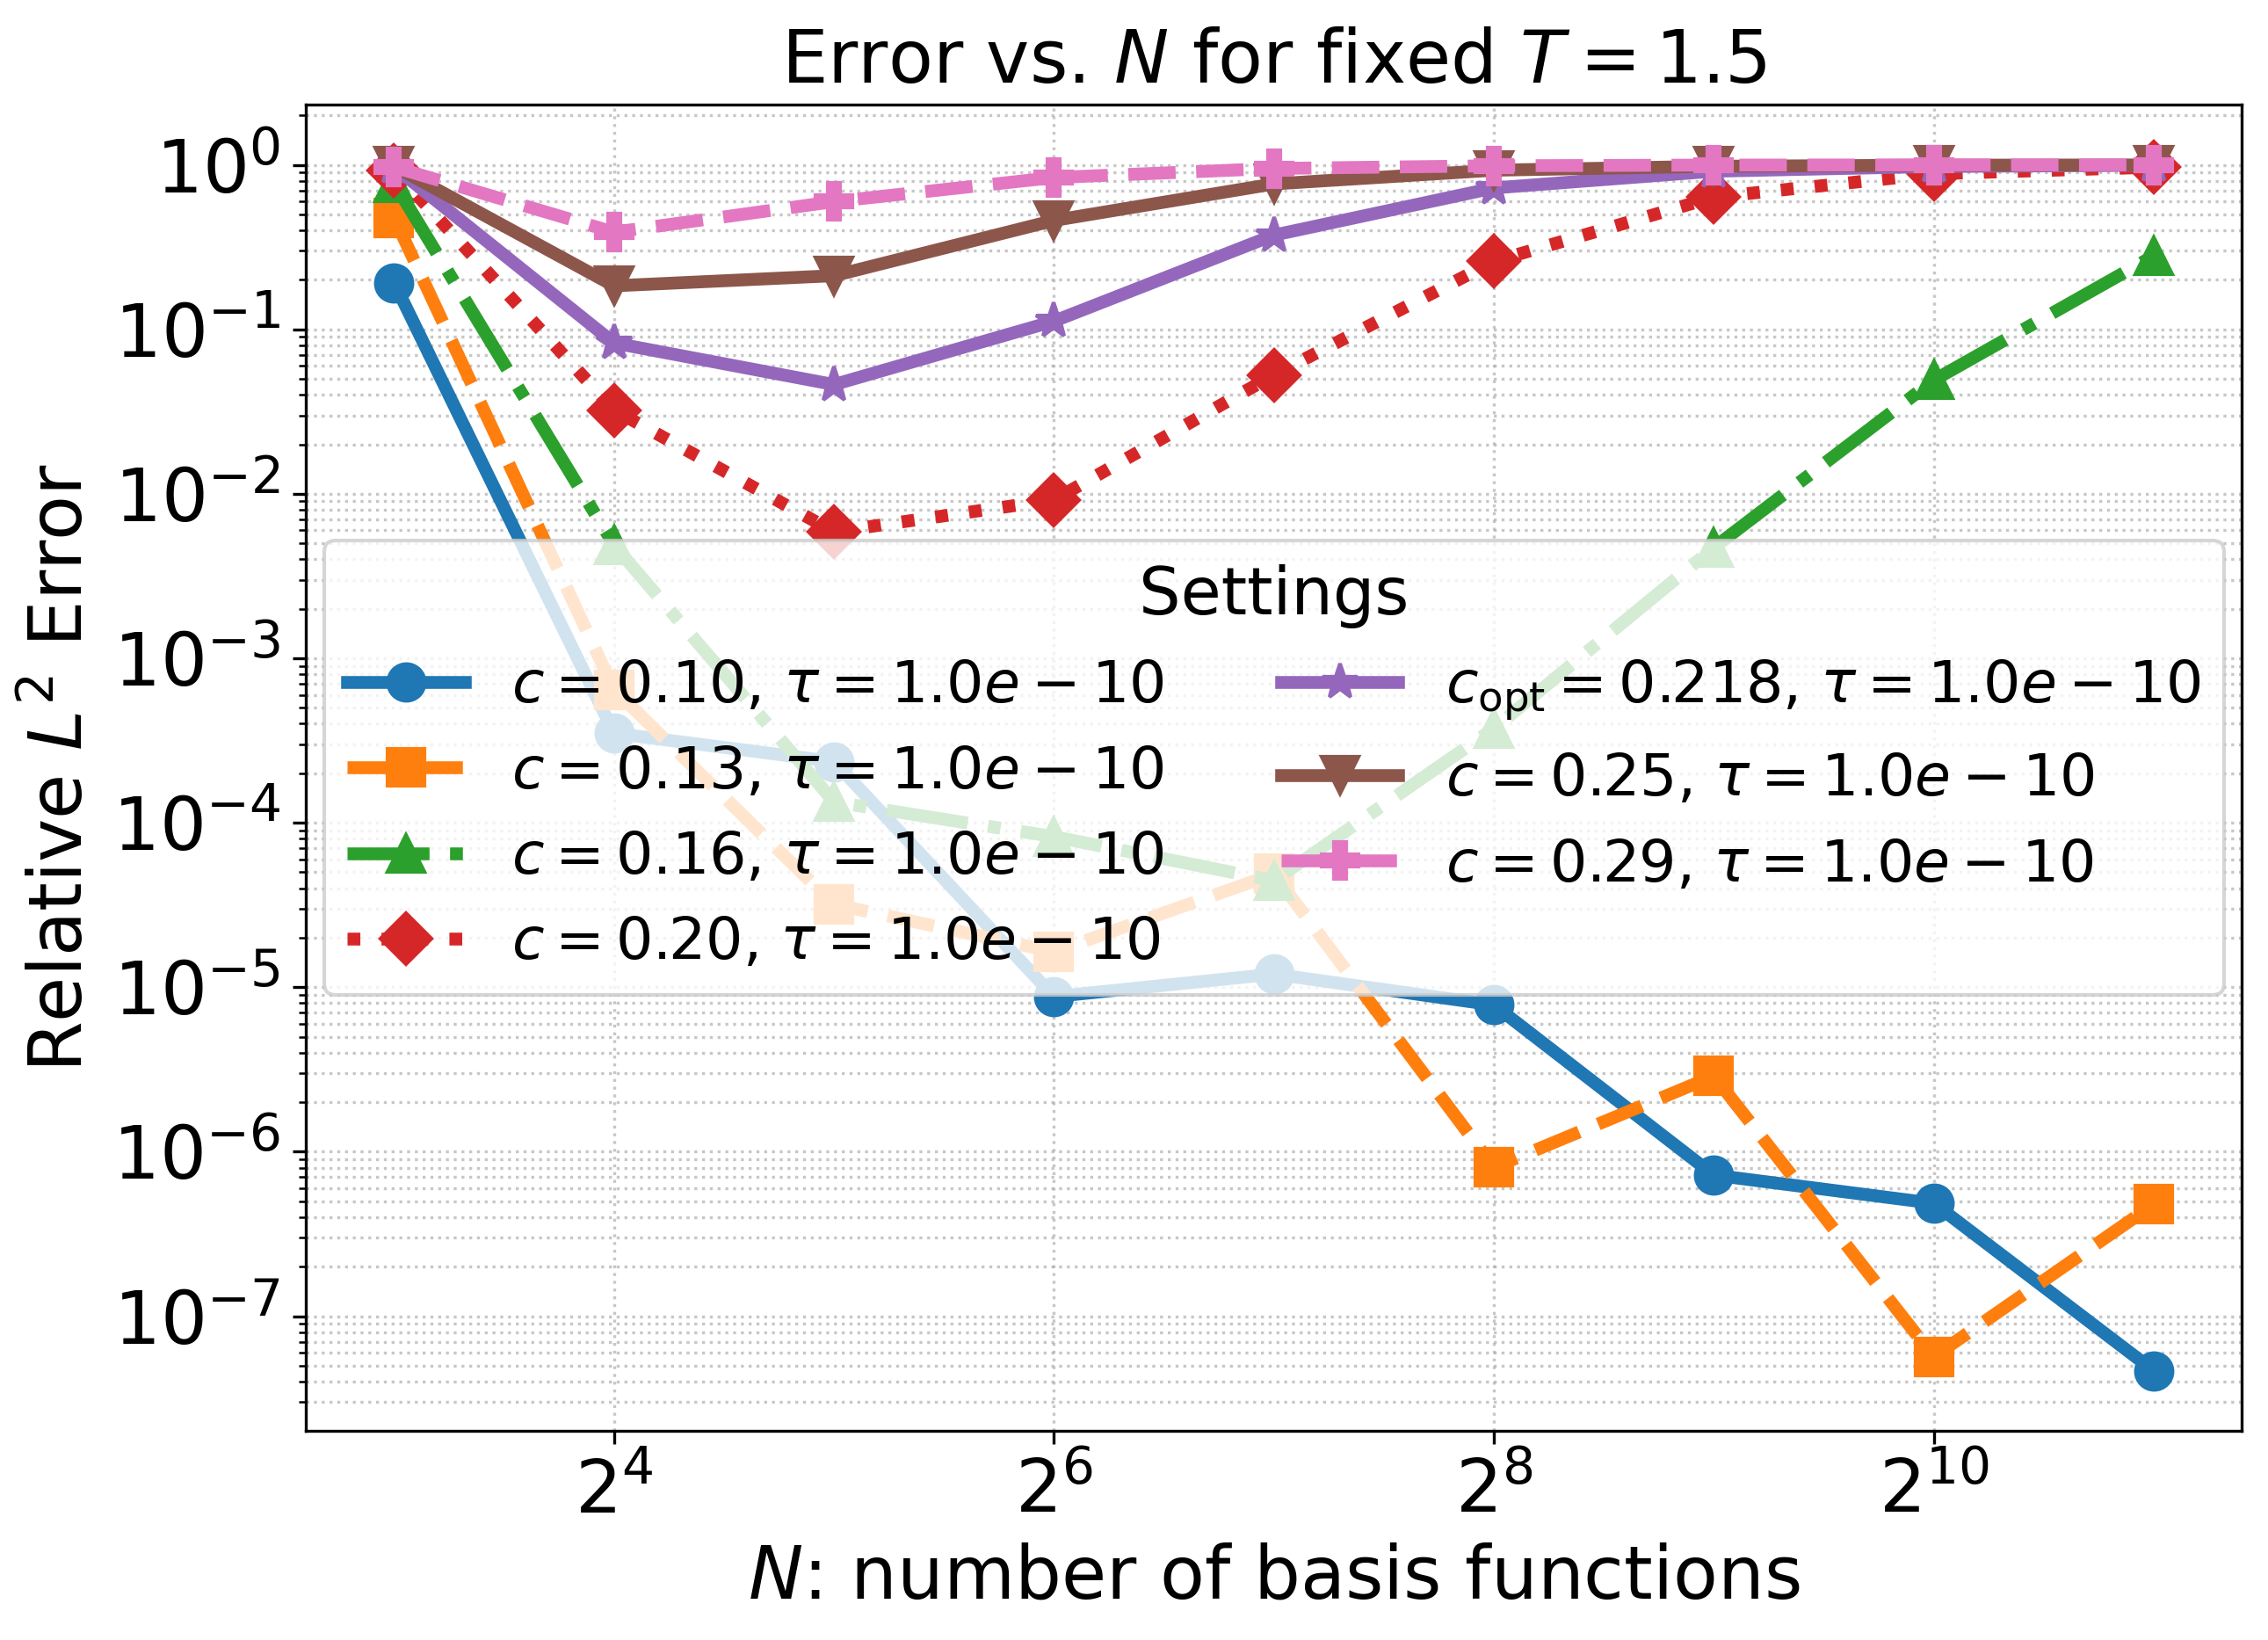

In [11]:
# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_val:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau_val:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
plt.xscale('log', base=2)

plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig5_reactiondiffusion.png')
#plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary c
T_fixed = 2.0
tau_val = 1e-10



# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_val)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.09820493, 0.13093991, 0.16367488, 0.19640986, 0.24551232, 0.29461479, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err, _, _ = run_rbf_solver(N, c_shape = c_val, tau = tau_val)
        errs.append(float(rel_l2_err))

    E[float(c_val)] = np.asarray(errs, dtype=float)


# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.1e} and c={c_val:.2f} are numerically identical.")

Fixed T = 2.0
c values used:
  c=9.820493e-02
  c=1.309399e-01
  c=1.636749e-01
  c=1.964099e-01
  c=2.455123e-01
  c=2.946148e-01
  c=1.636749e-01


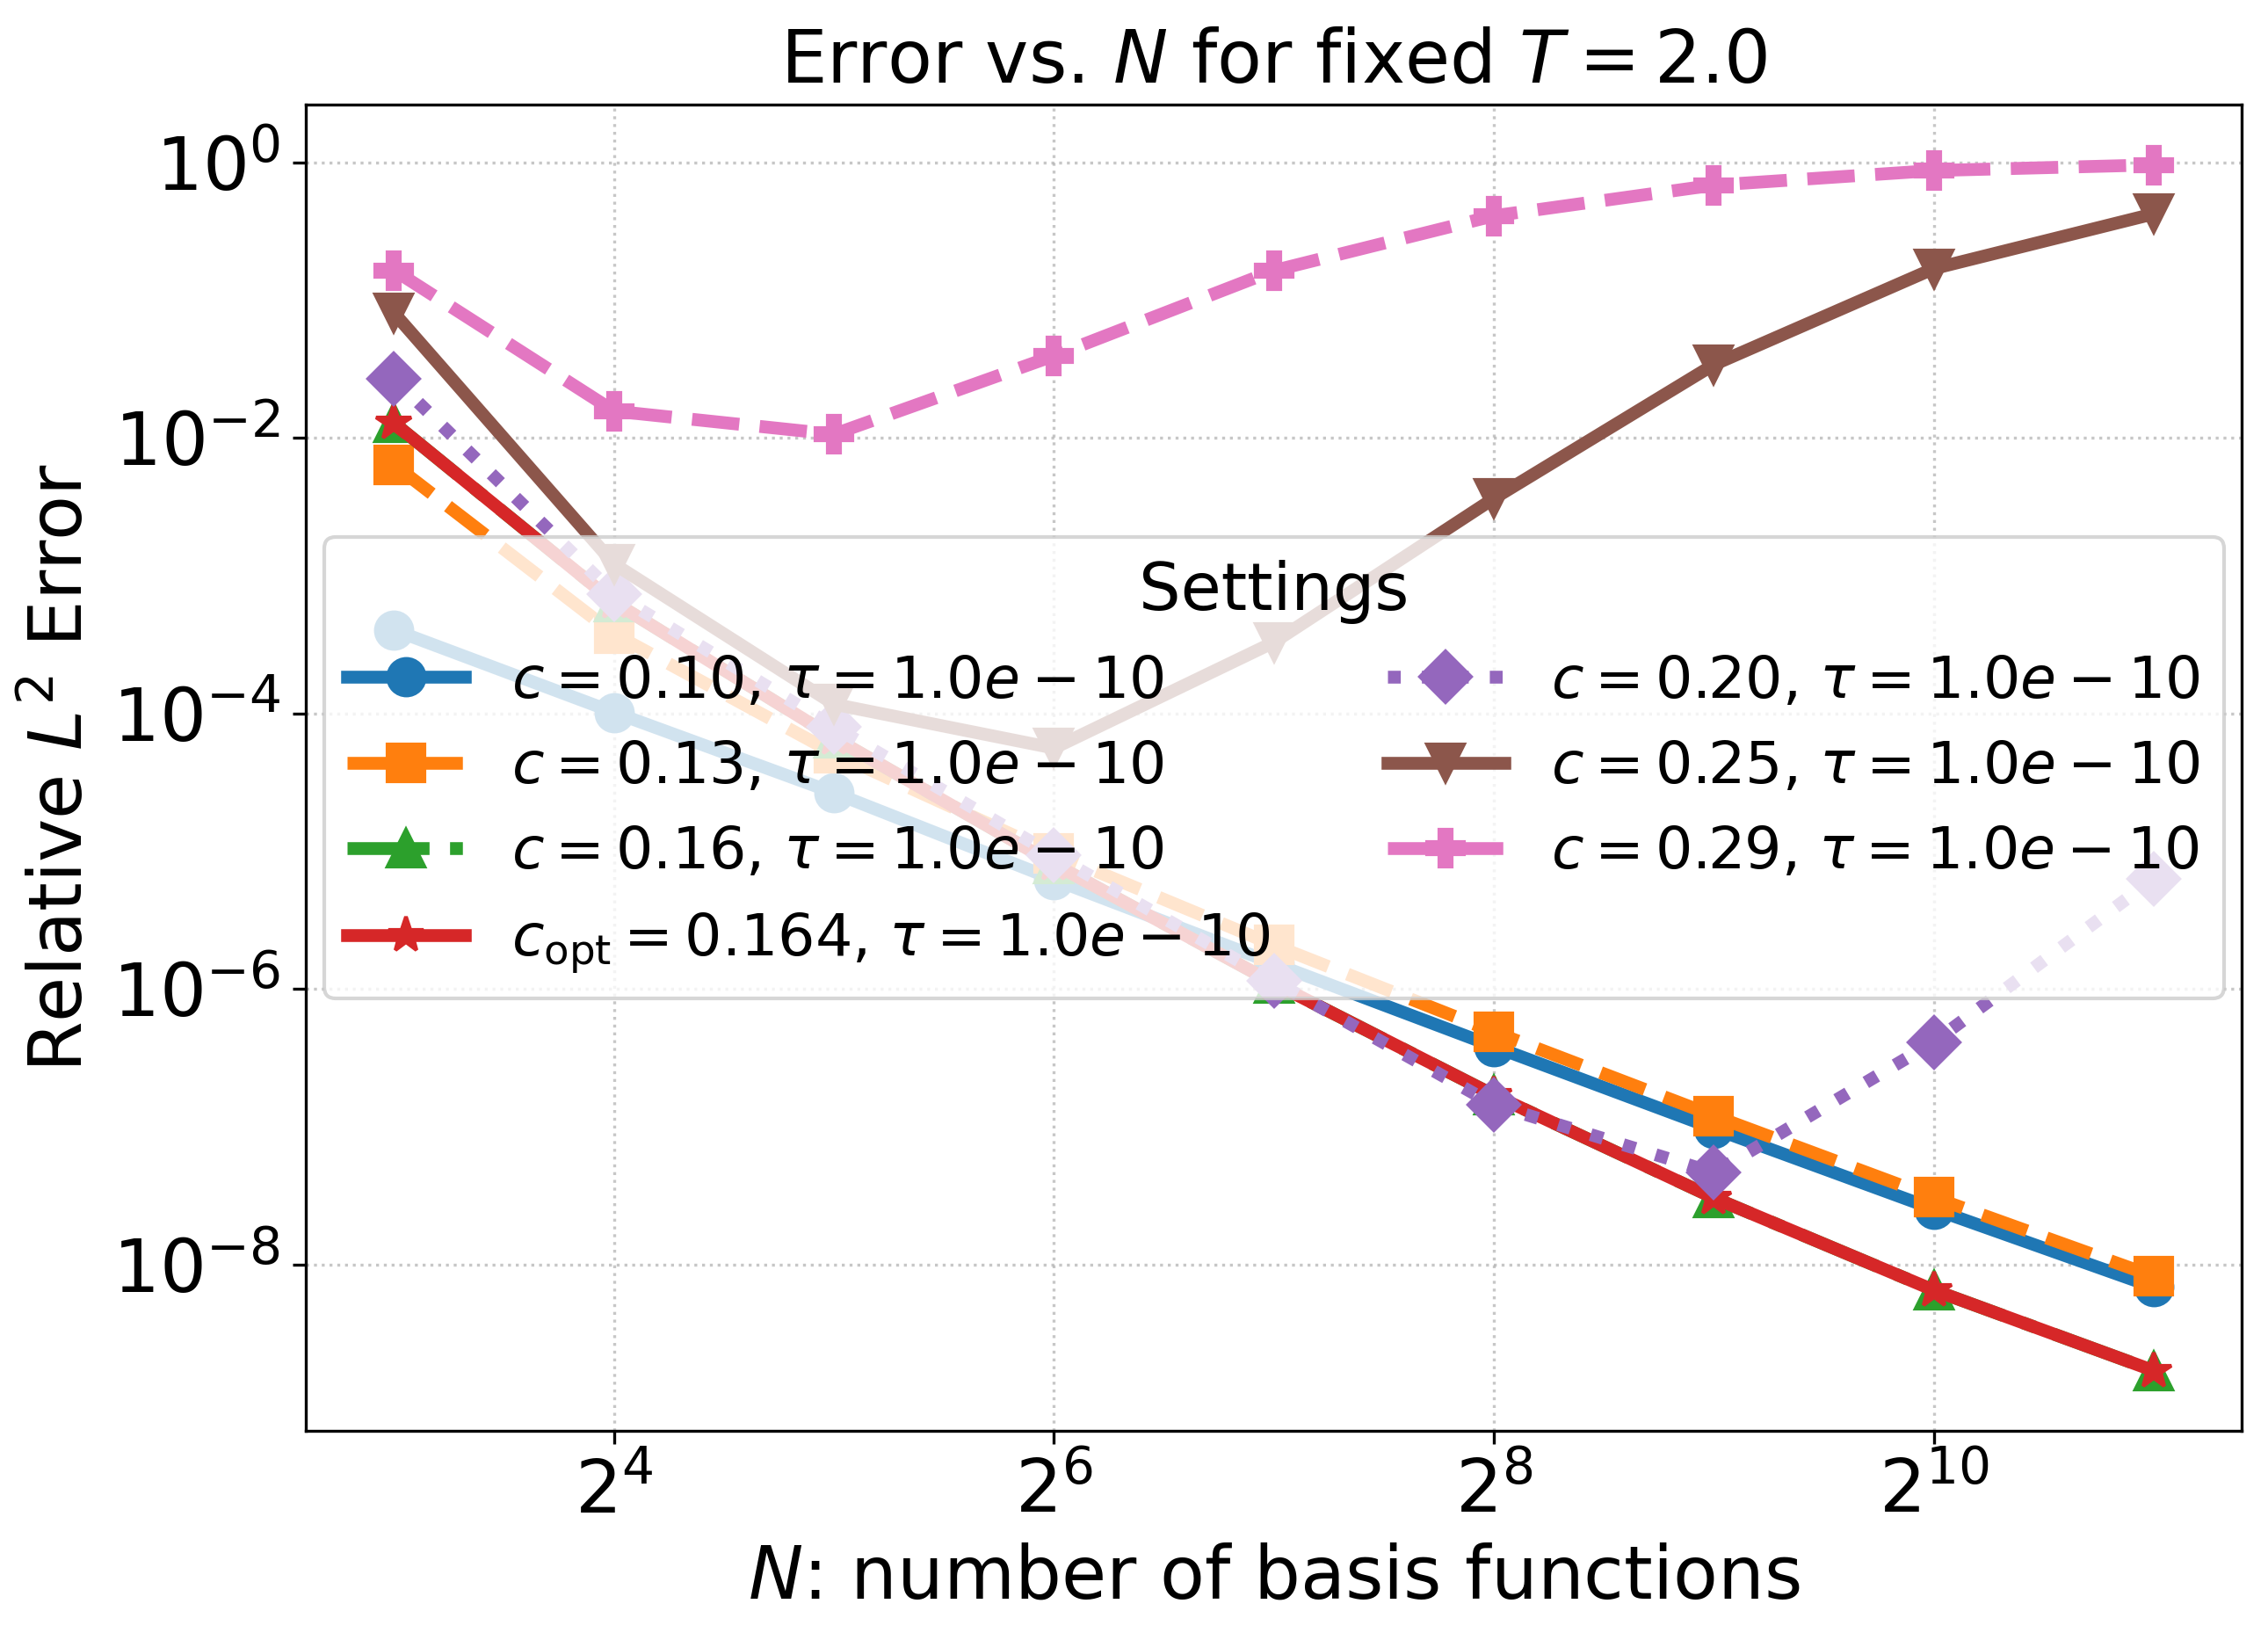

In [13]:
# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_val:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau_val:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )
# If you prefer log-x since N doubles, uncomment:
plt.xscale('log', base=2)

plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig6_reactiondiffusion.png')
#plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle




# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary c
T_fixed = 4.0
tau_val = 1e-10



# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau_val)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.09820493, 0.13093991, 0.16367488, 0.19640986, 0.24551232, 0.29461479, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err, _, _ = run_rbf_solver(N, c_shape = c_val, tau = tau_val, T_cent = T_fixed)
        errs.append(float(rel_l2_err))

    E[float(c_val)] = np.asarray(errs, dtype=float)


# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.1e} and c={c_val:.2f} are numerically identical.")

Fixed T = 4.0
c values used:
  c=9.820493e-02
  c=1.309399e-01
  c=1.636749e-01
  c=1.964099e-01
  c=2.455123e-01
  c=2.946148e-01
  c=8.183744e-02


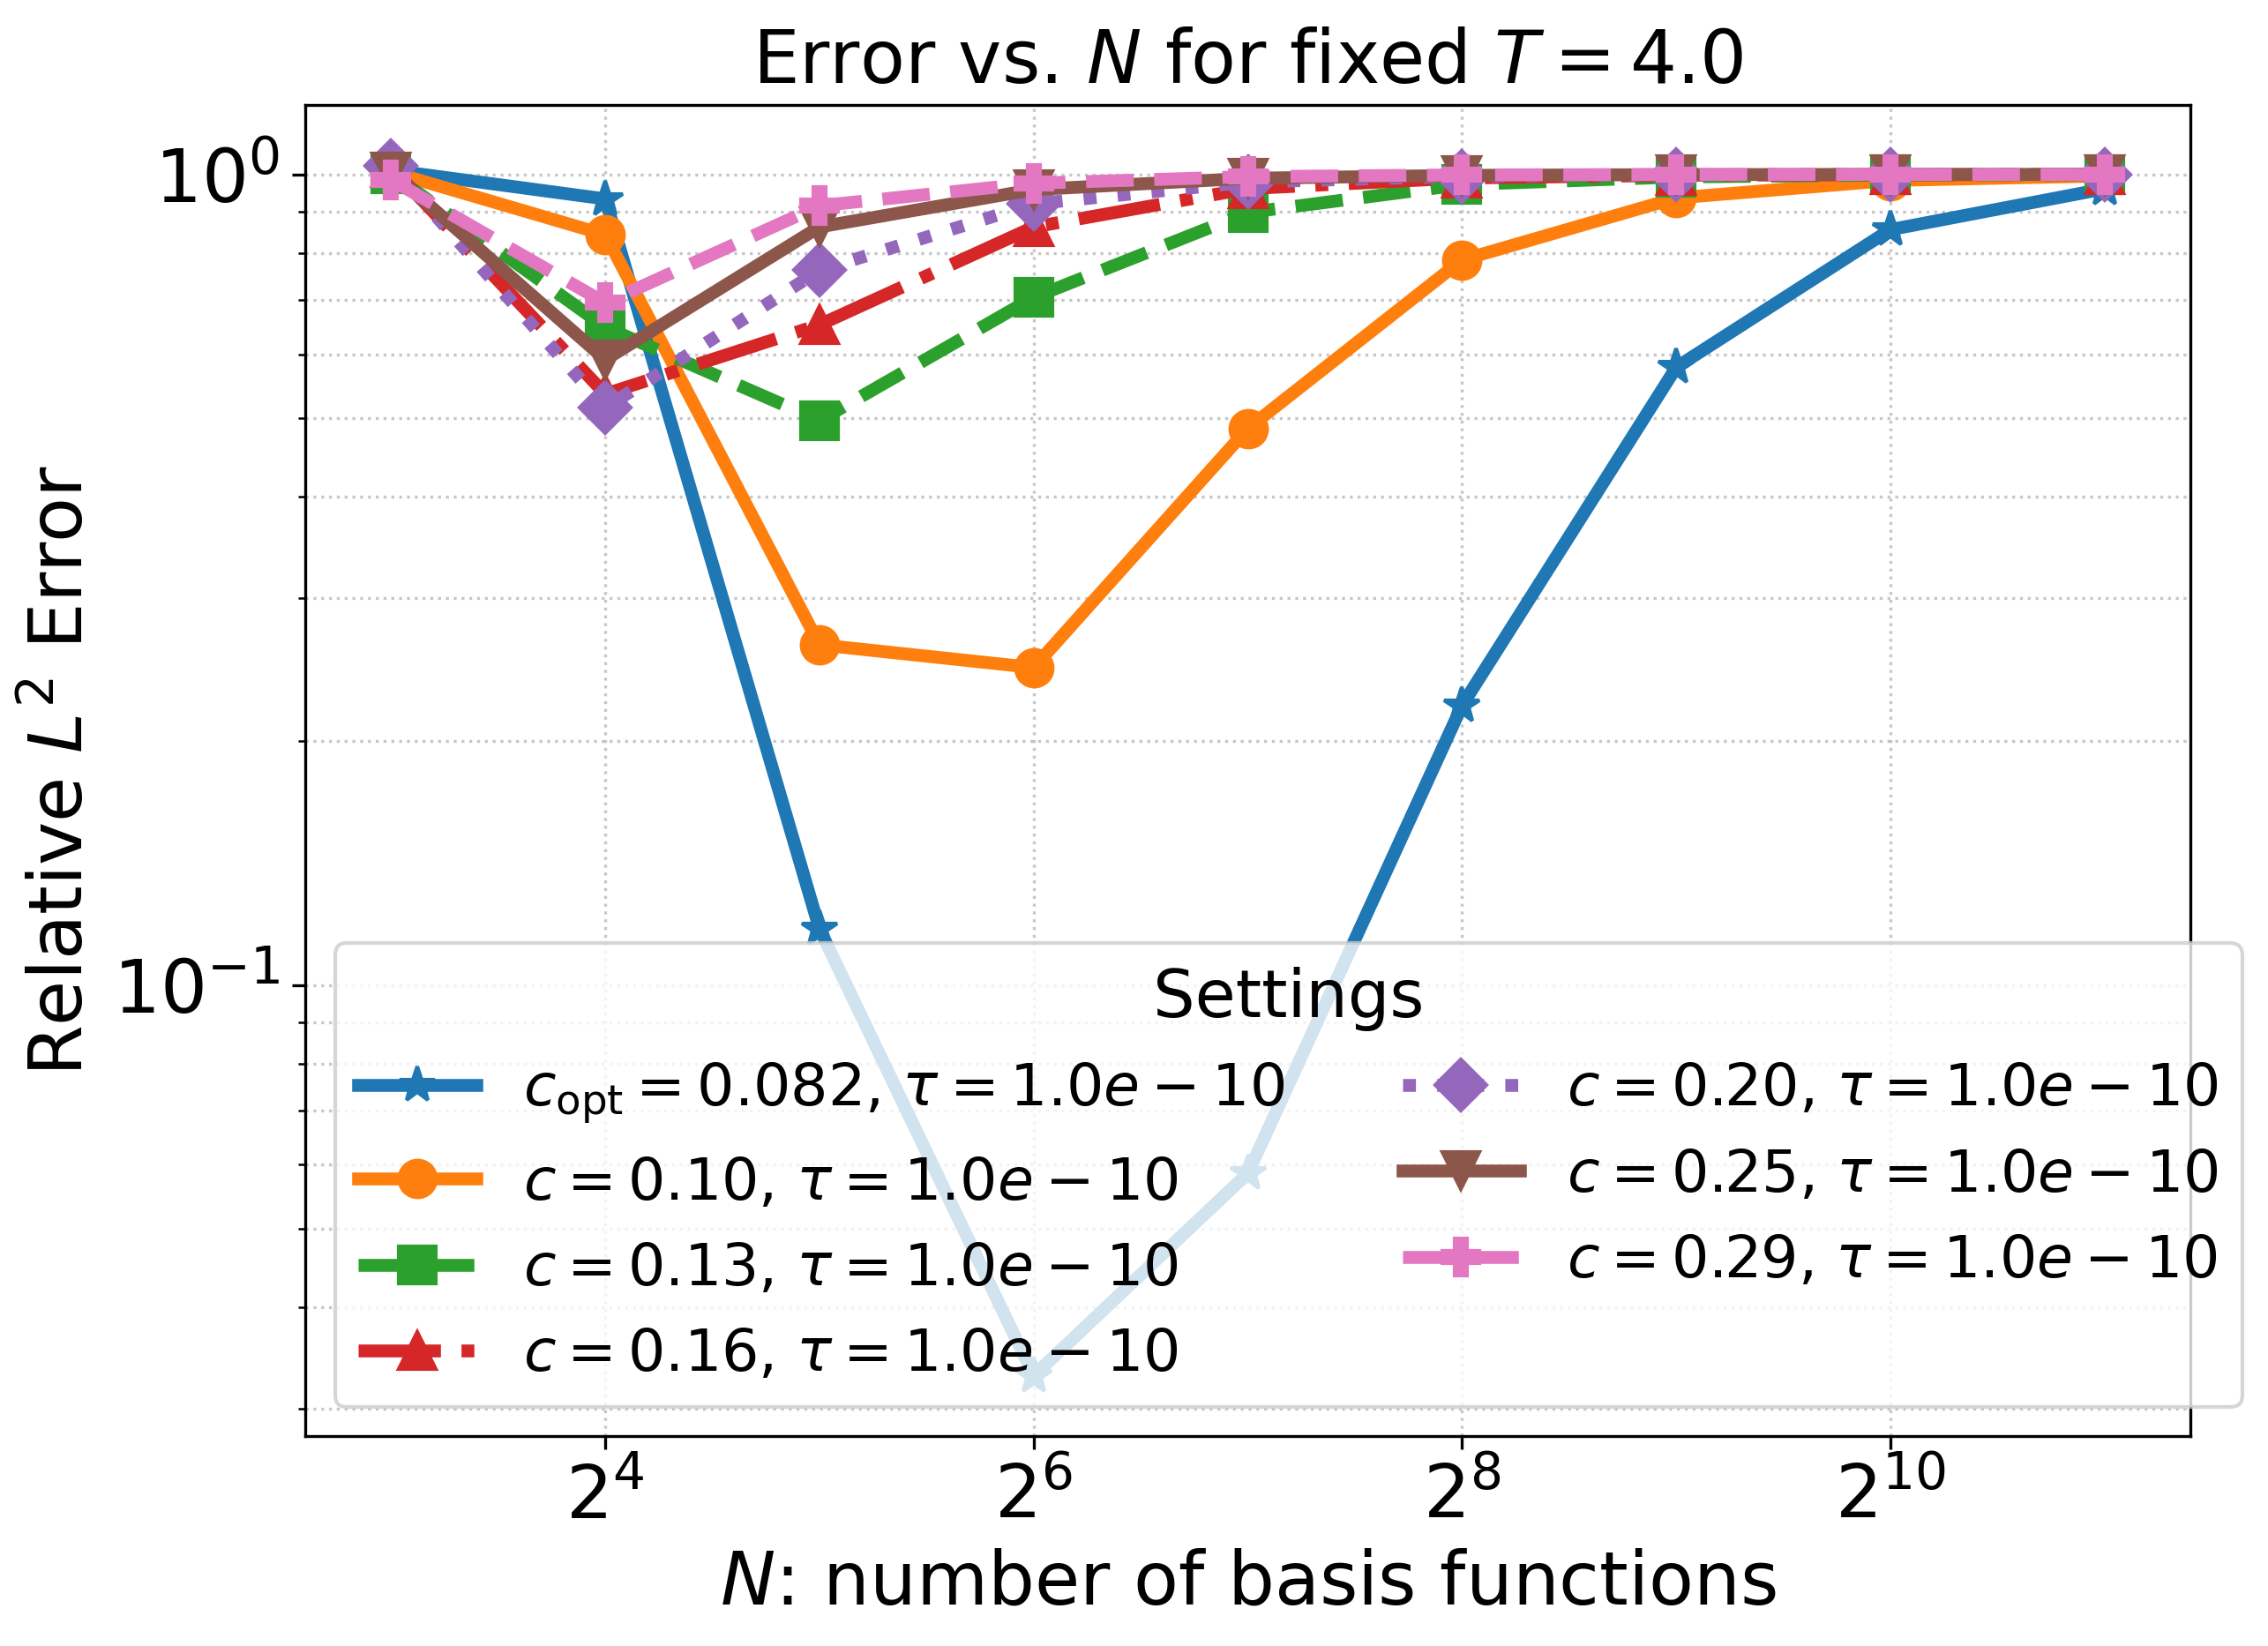

In [15]:
# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_val:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau_val:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
plt.xscale('log', base=2)

plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=20)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig7_reactiondiffusion.png')
#plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary c
T_fixed = 6.0
tau_val = 1e-10



# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))


c_optim = c_from_T(T_fixed, tau_val)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.09820493, 0.13093991, 0.16367488, 0.19640986, 0.24551232, 0.29461479, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err, _, _ = run_rbf_solver(N, c_shape = c_val, tau = tau_val, T_cent = T_fixed)
        errs.append(float(rel_l2_err))

    E[float(c_val)] = np.asarray(errs, dtype=float)


# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.1e} and c={c_val:.2f} are numerically identical.")

Fixed T = 6.0
c values used:
  c=9.820493e-02
  c=1.309399e-01
  c=1.636749e-01
  c=1.964099e-01
  c=2.455123e-01
  c=2.946148e-01
  c=5.455829e-02


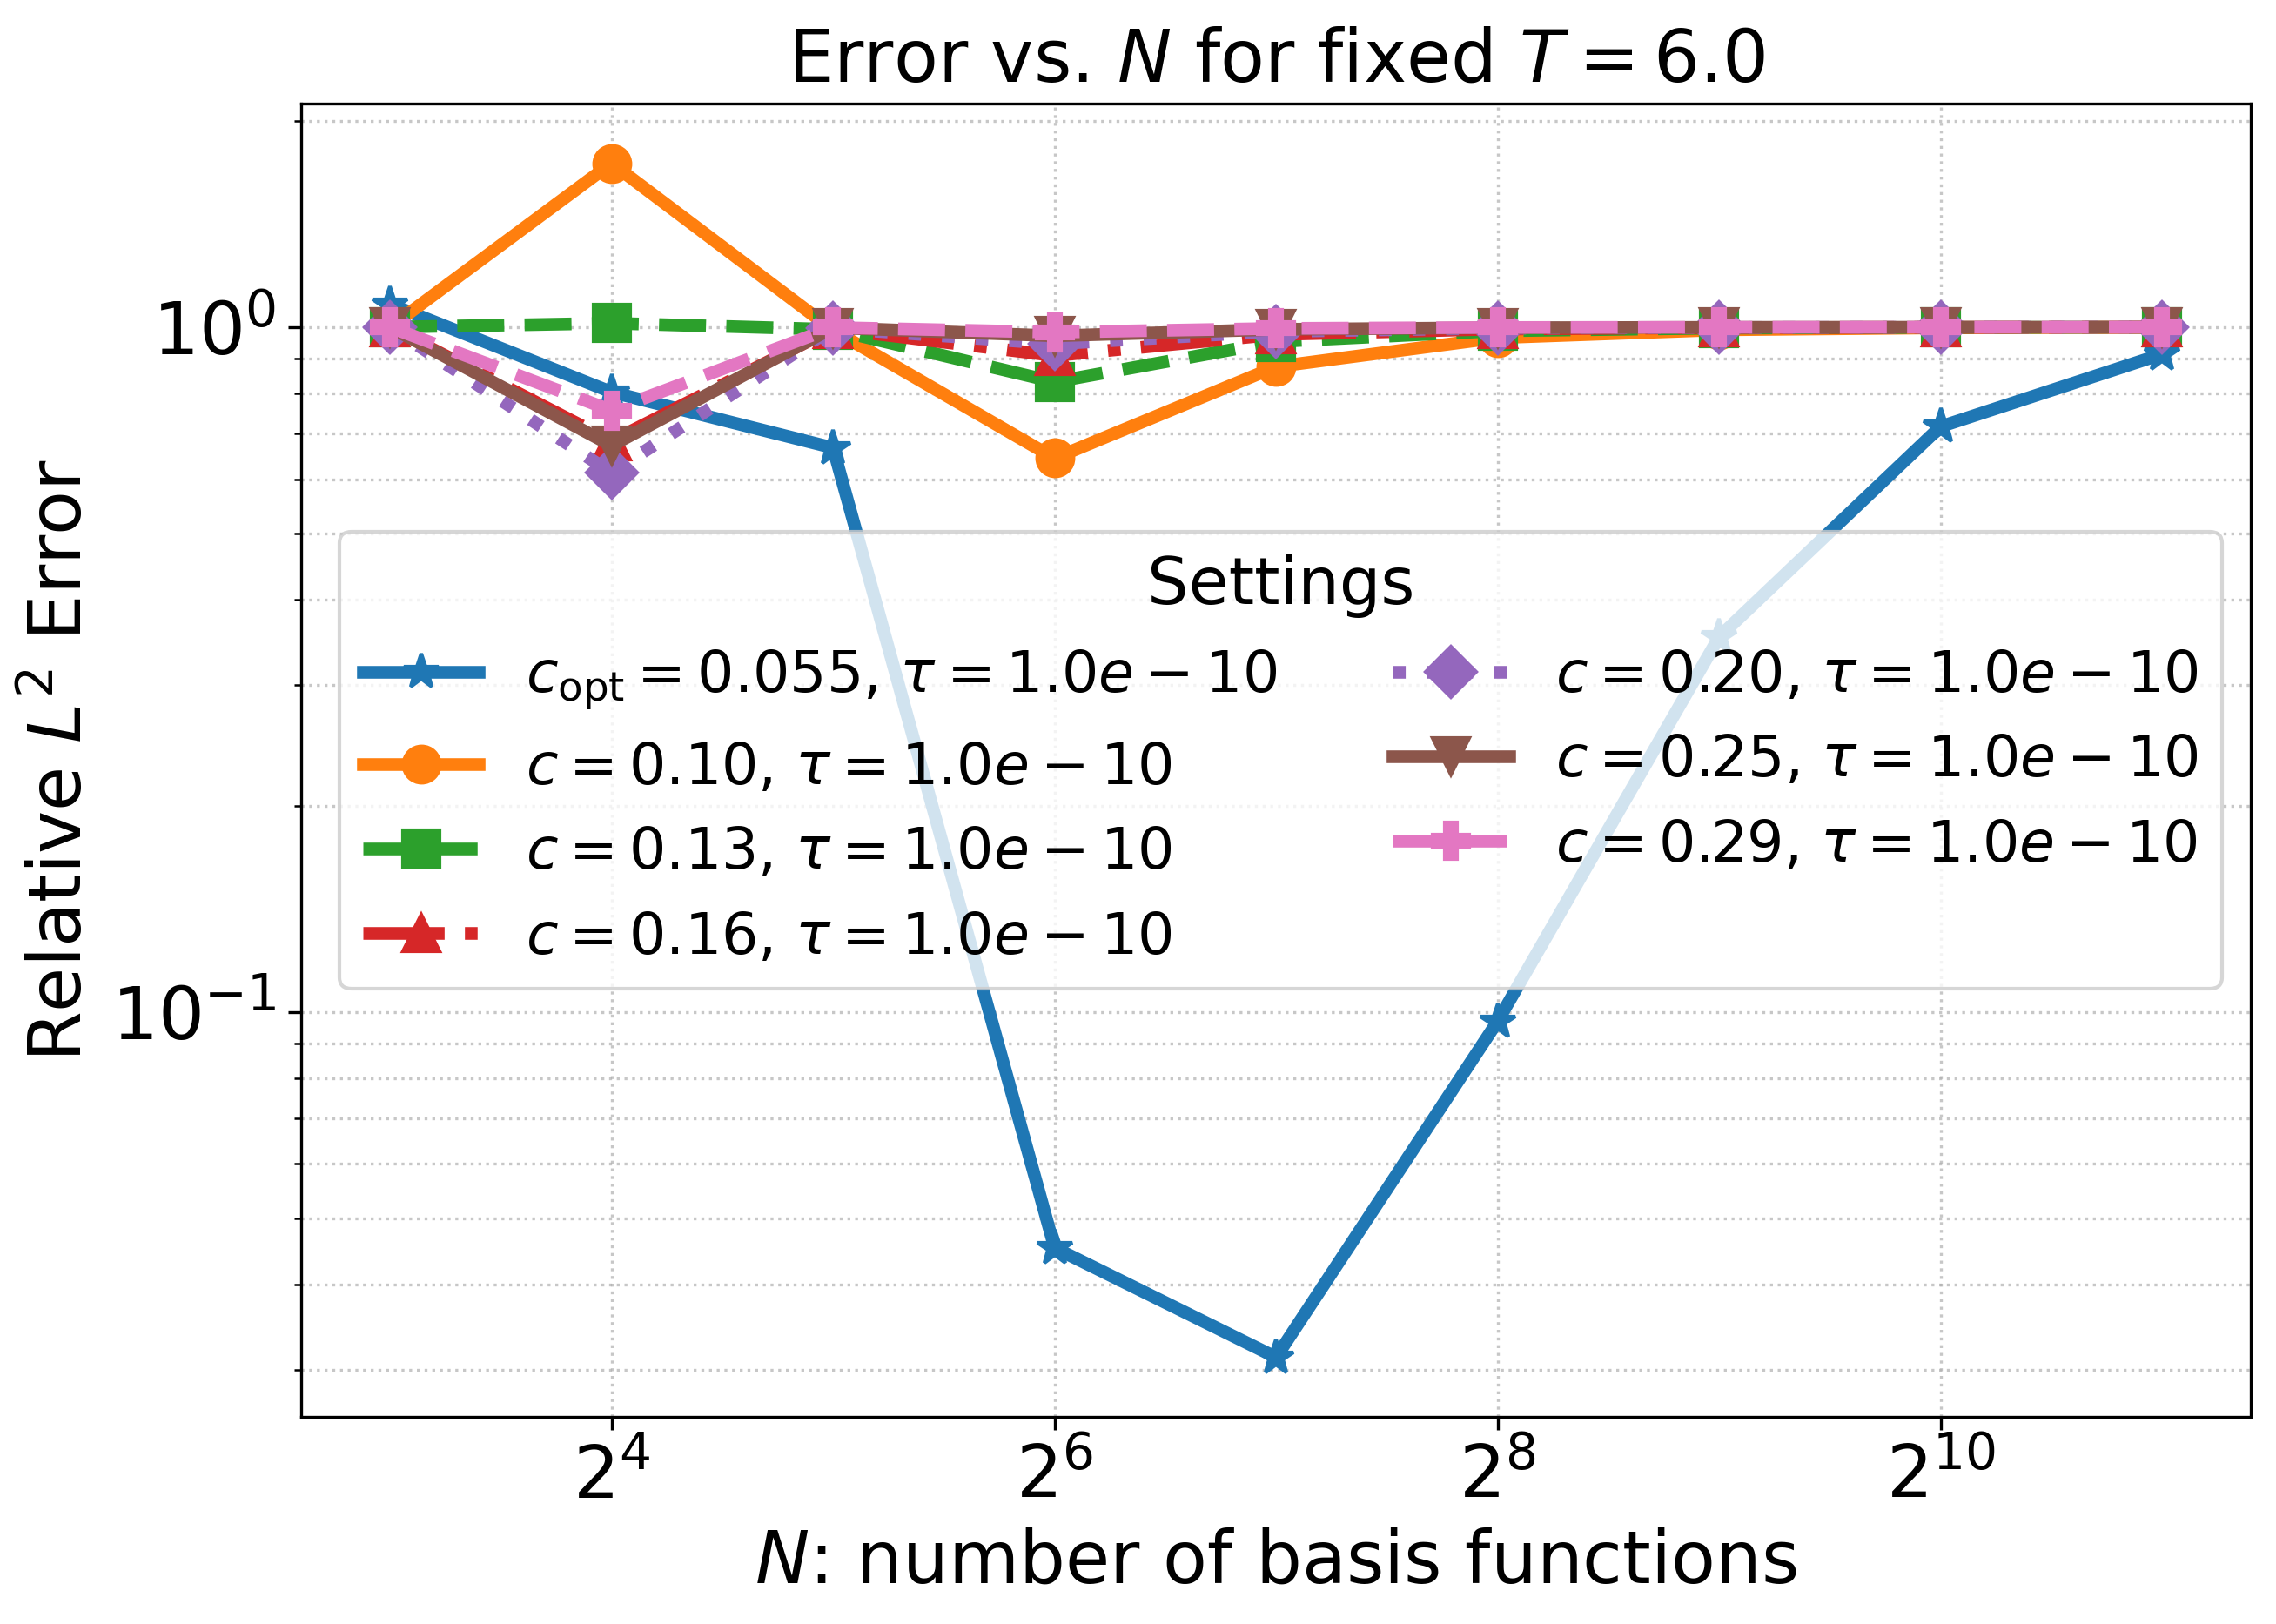

In [17]:
# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau_val:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau_val:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
plt.xscale('log', base=2)

plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig8_reactiondiffusion.png')
#plt.show()

# Experiment for fixed value of $T$, variation of $\tau$ and $c = c(T, \tau)$

In [18]:
# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary tau
T_fixed = 1.5
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Cs_used = {}  # tau -> c actually used (for logging)


print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau)
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err,_,_ = run_rbf_solver(N, T_cent=T_fixed, c_shape=float(c_val), tau=float(tau))
        
        errs.append(float(rel_l2_err))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Cs_used[float(tau)] = float(c_val)

Fixed T = 1.5
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


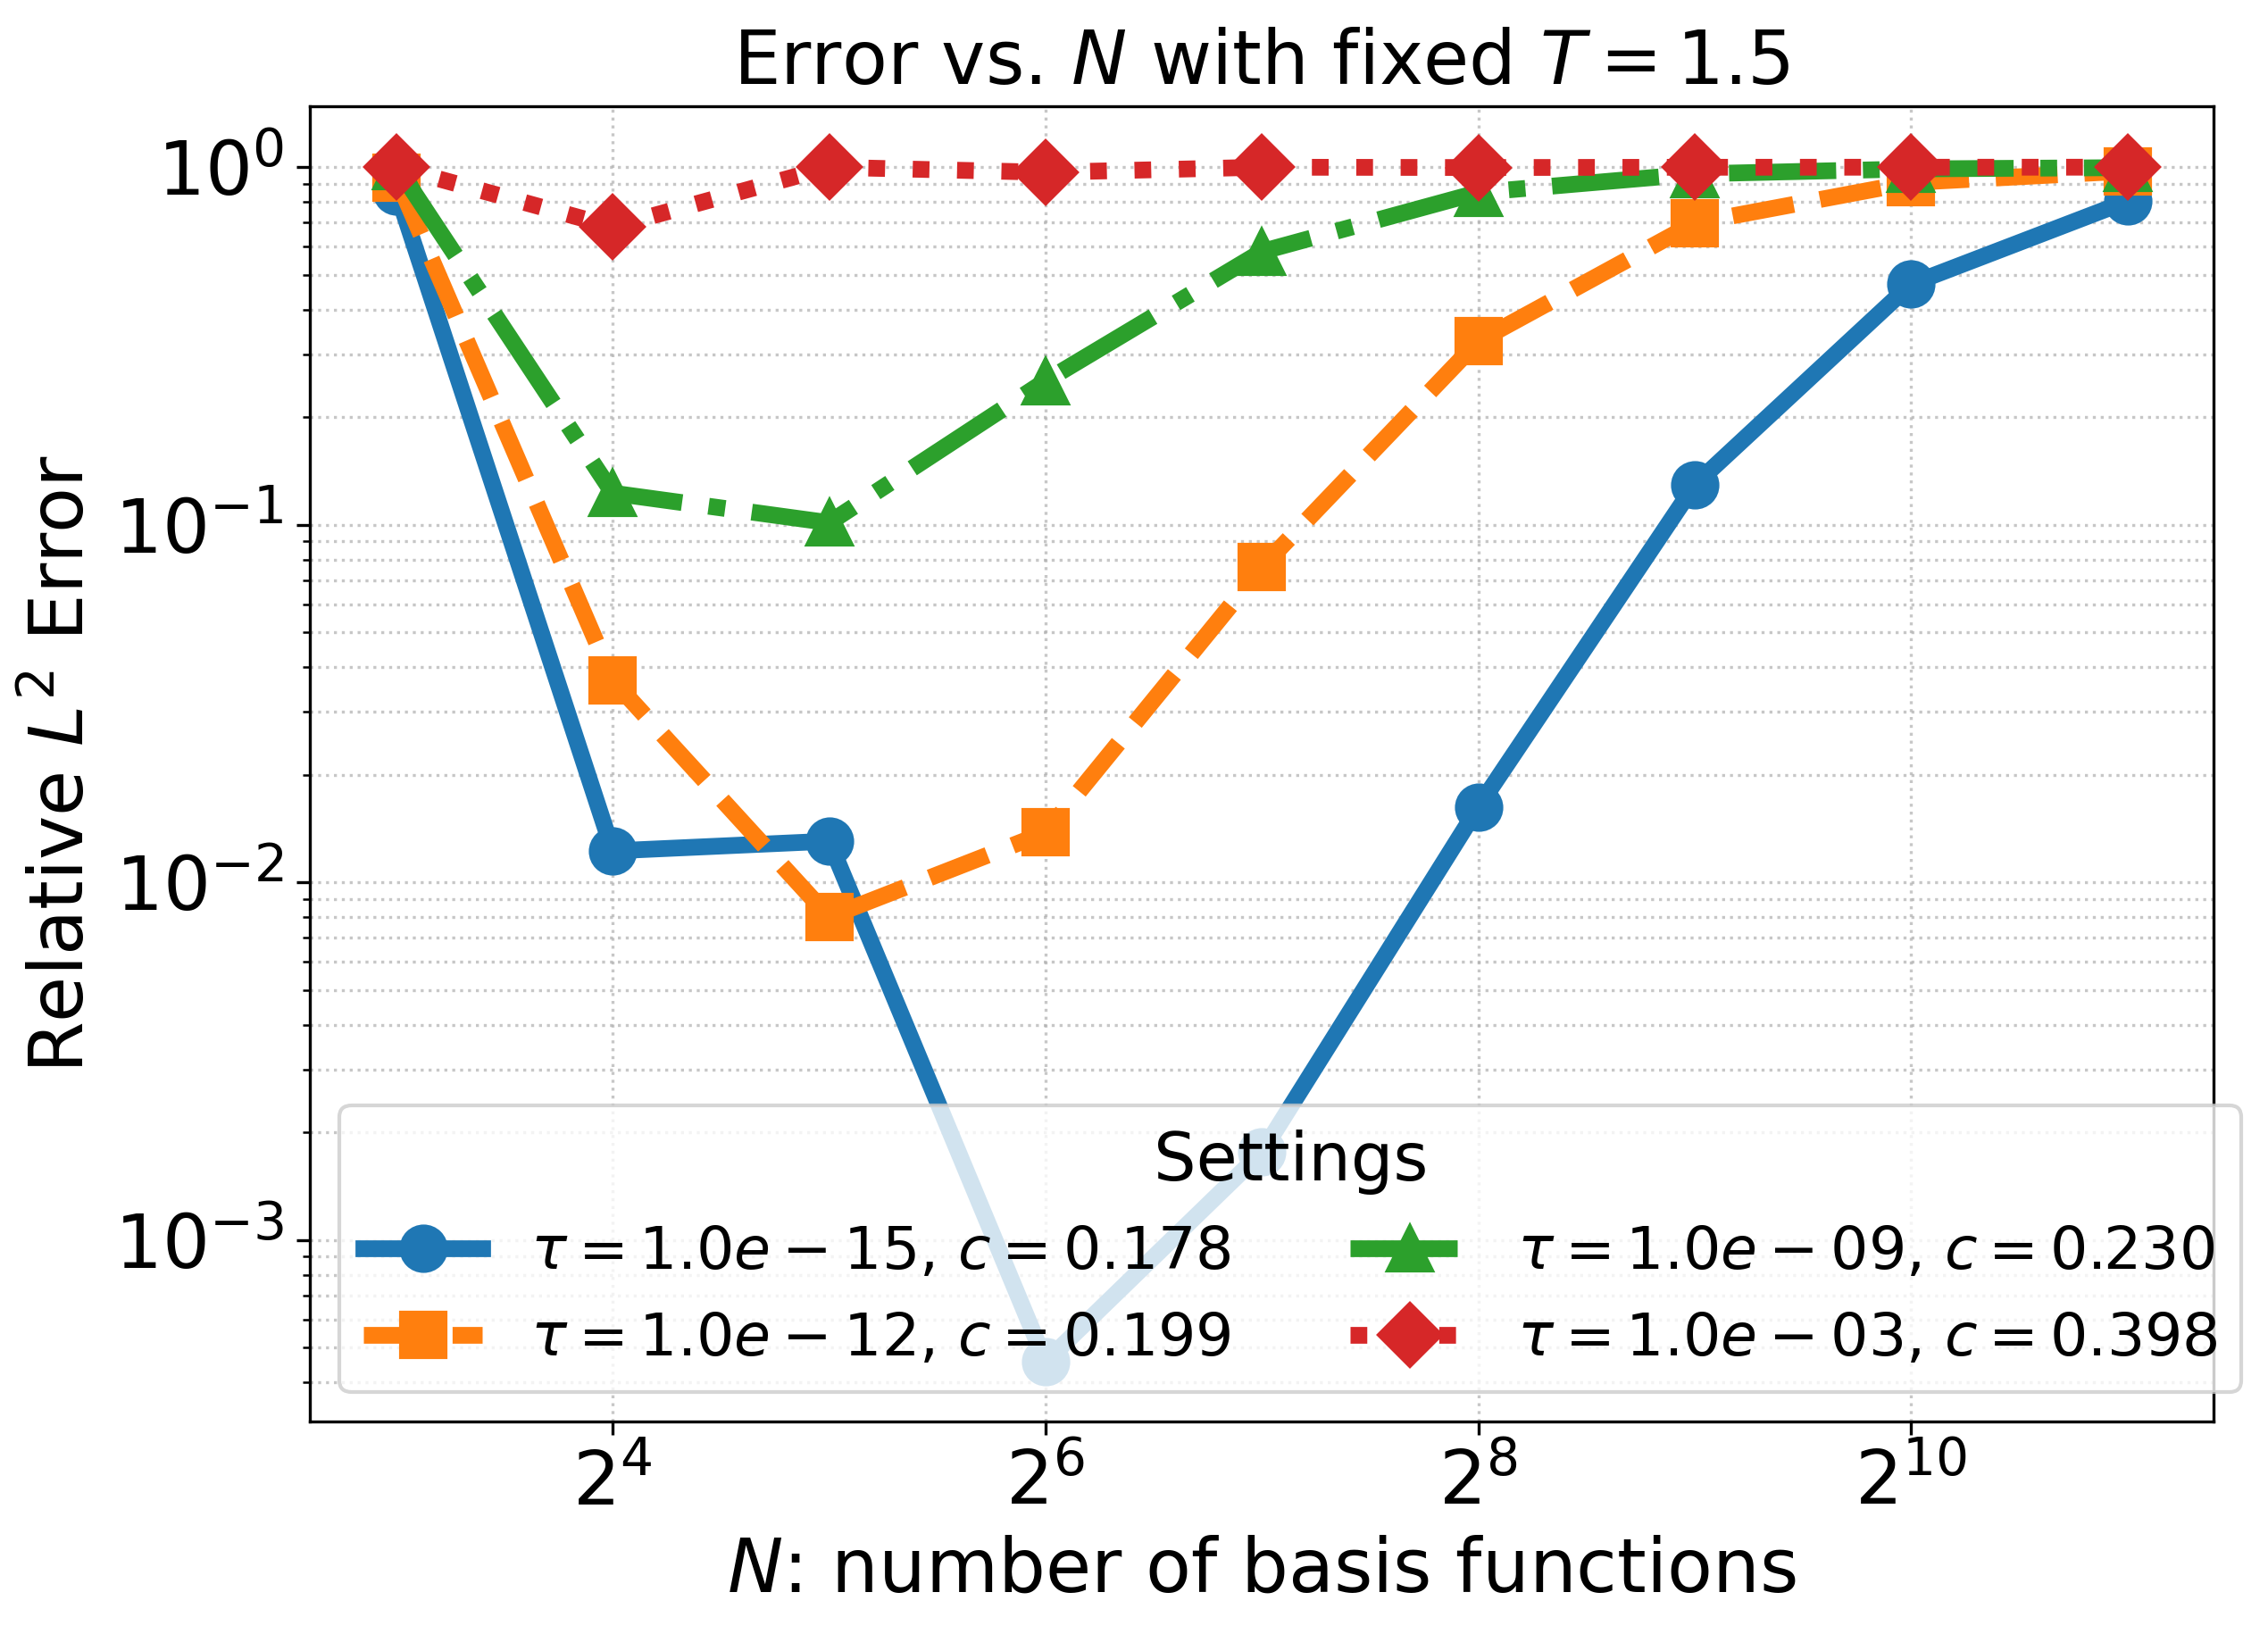

In [19]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})


# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=4.5,
        markersize=12,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=20)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig9_reactiondiffusion.png')
#plt.show()

In [20]:
# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary tau
T_fixed = 2.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Cs_used = {}  # tau -> c actually used (for logging)


print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau)
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err,_,_ = run_rbf_solver(N, c_shape=float(c_val), tau=float(tau))
        
        errs.append(float(rel_l2_err))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Cs_used[float(tau)] = float(c_val)

Fixed T = 2.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


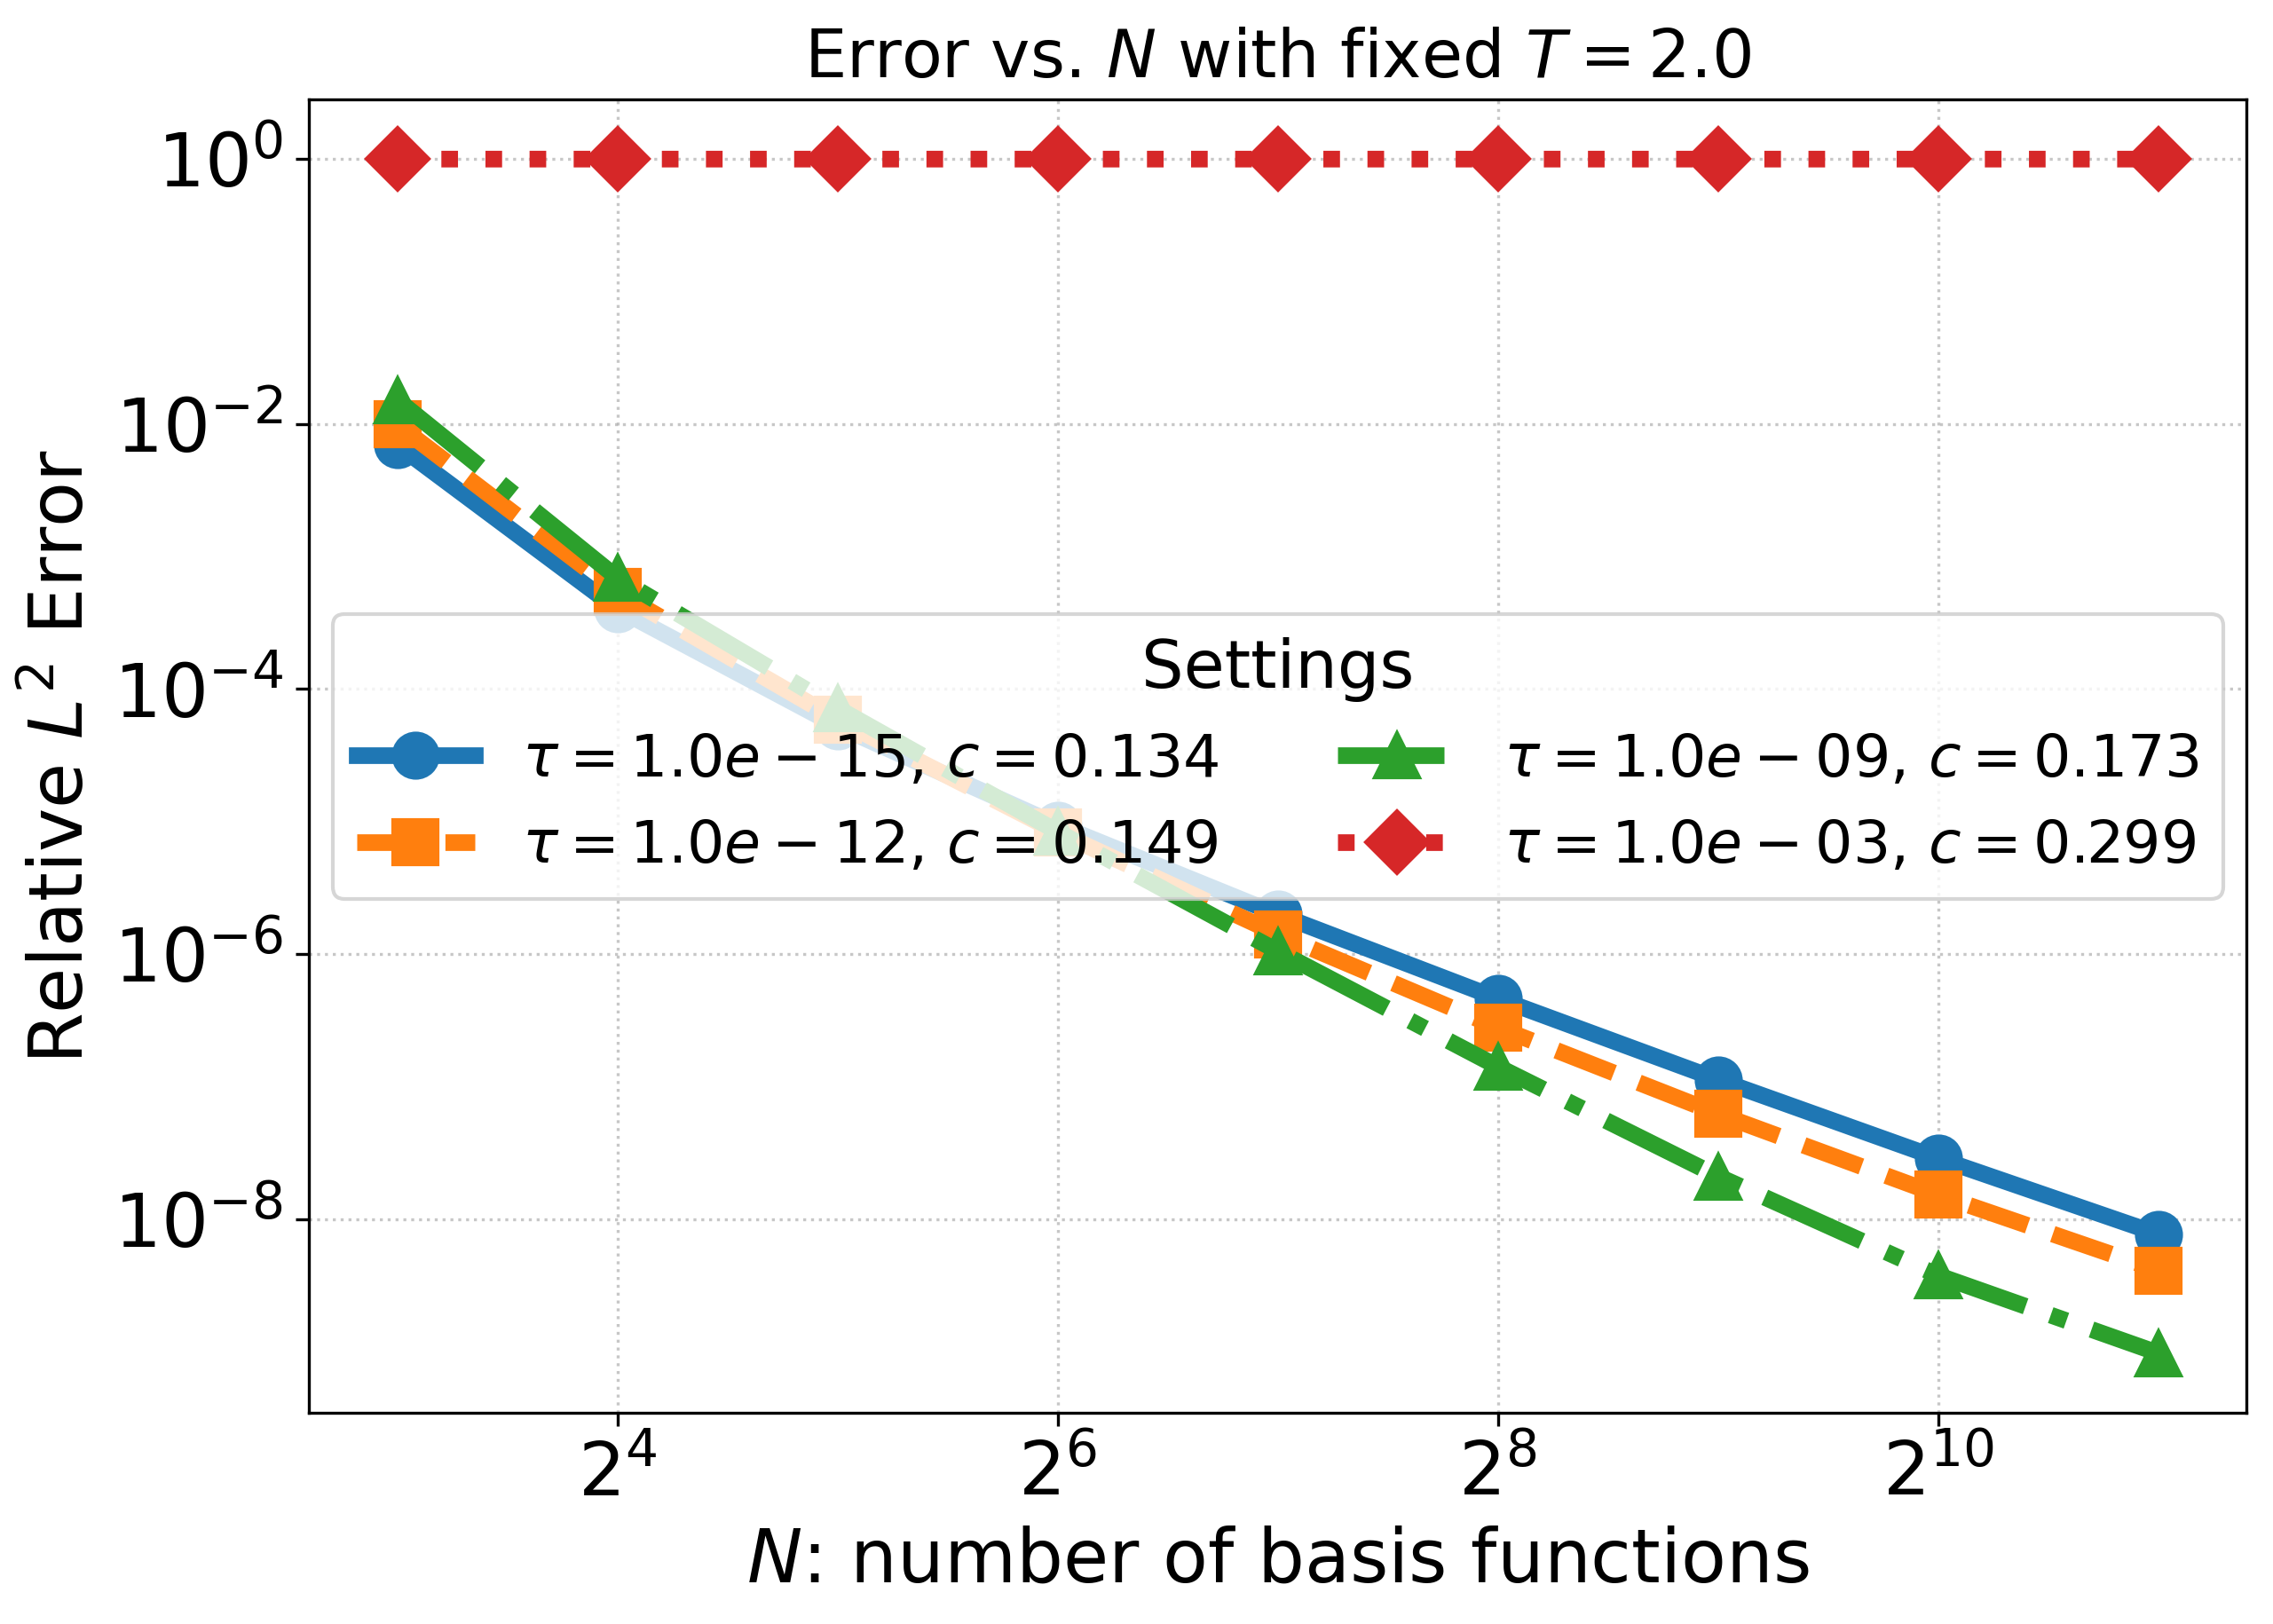

In [21]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})


# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=4.5,
        markersize=12,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig10_reactiondiffusion.png')
#plt.show()

In [22]:
# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary tau
T_fixed = 4.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Cs_used = {}  # tau -> c actually used (for logging)


print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau)
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err,_,_ = run_rbf_solver(N, T_cent = T_fixed, c_shape=float(c_val), tau=float(tau))
        
        errs.append(float(rel_l2_err))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Cs_used[float(tau)] = float(c_val)

Fixed T = 4.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


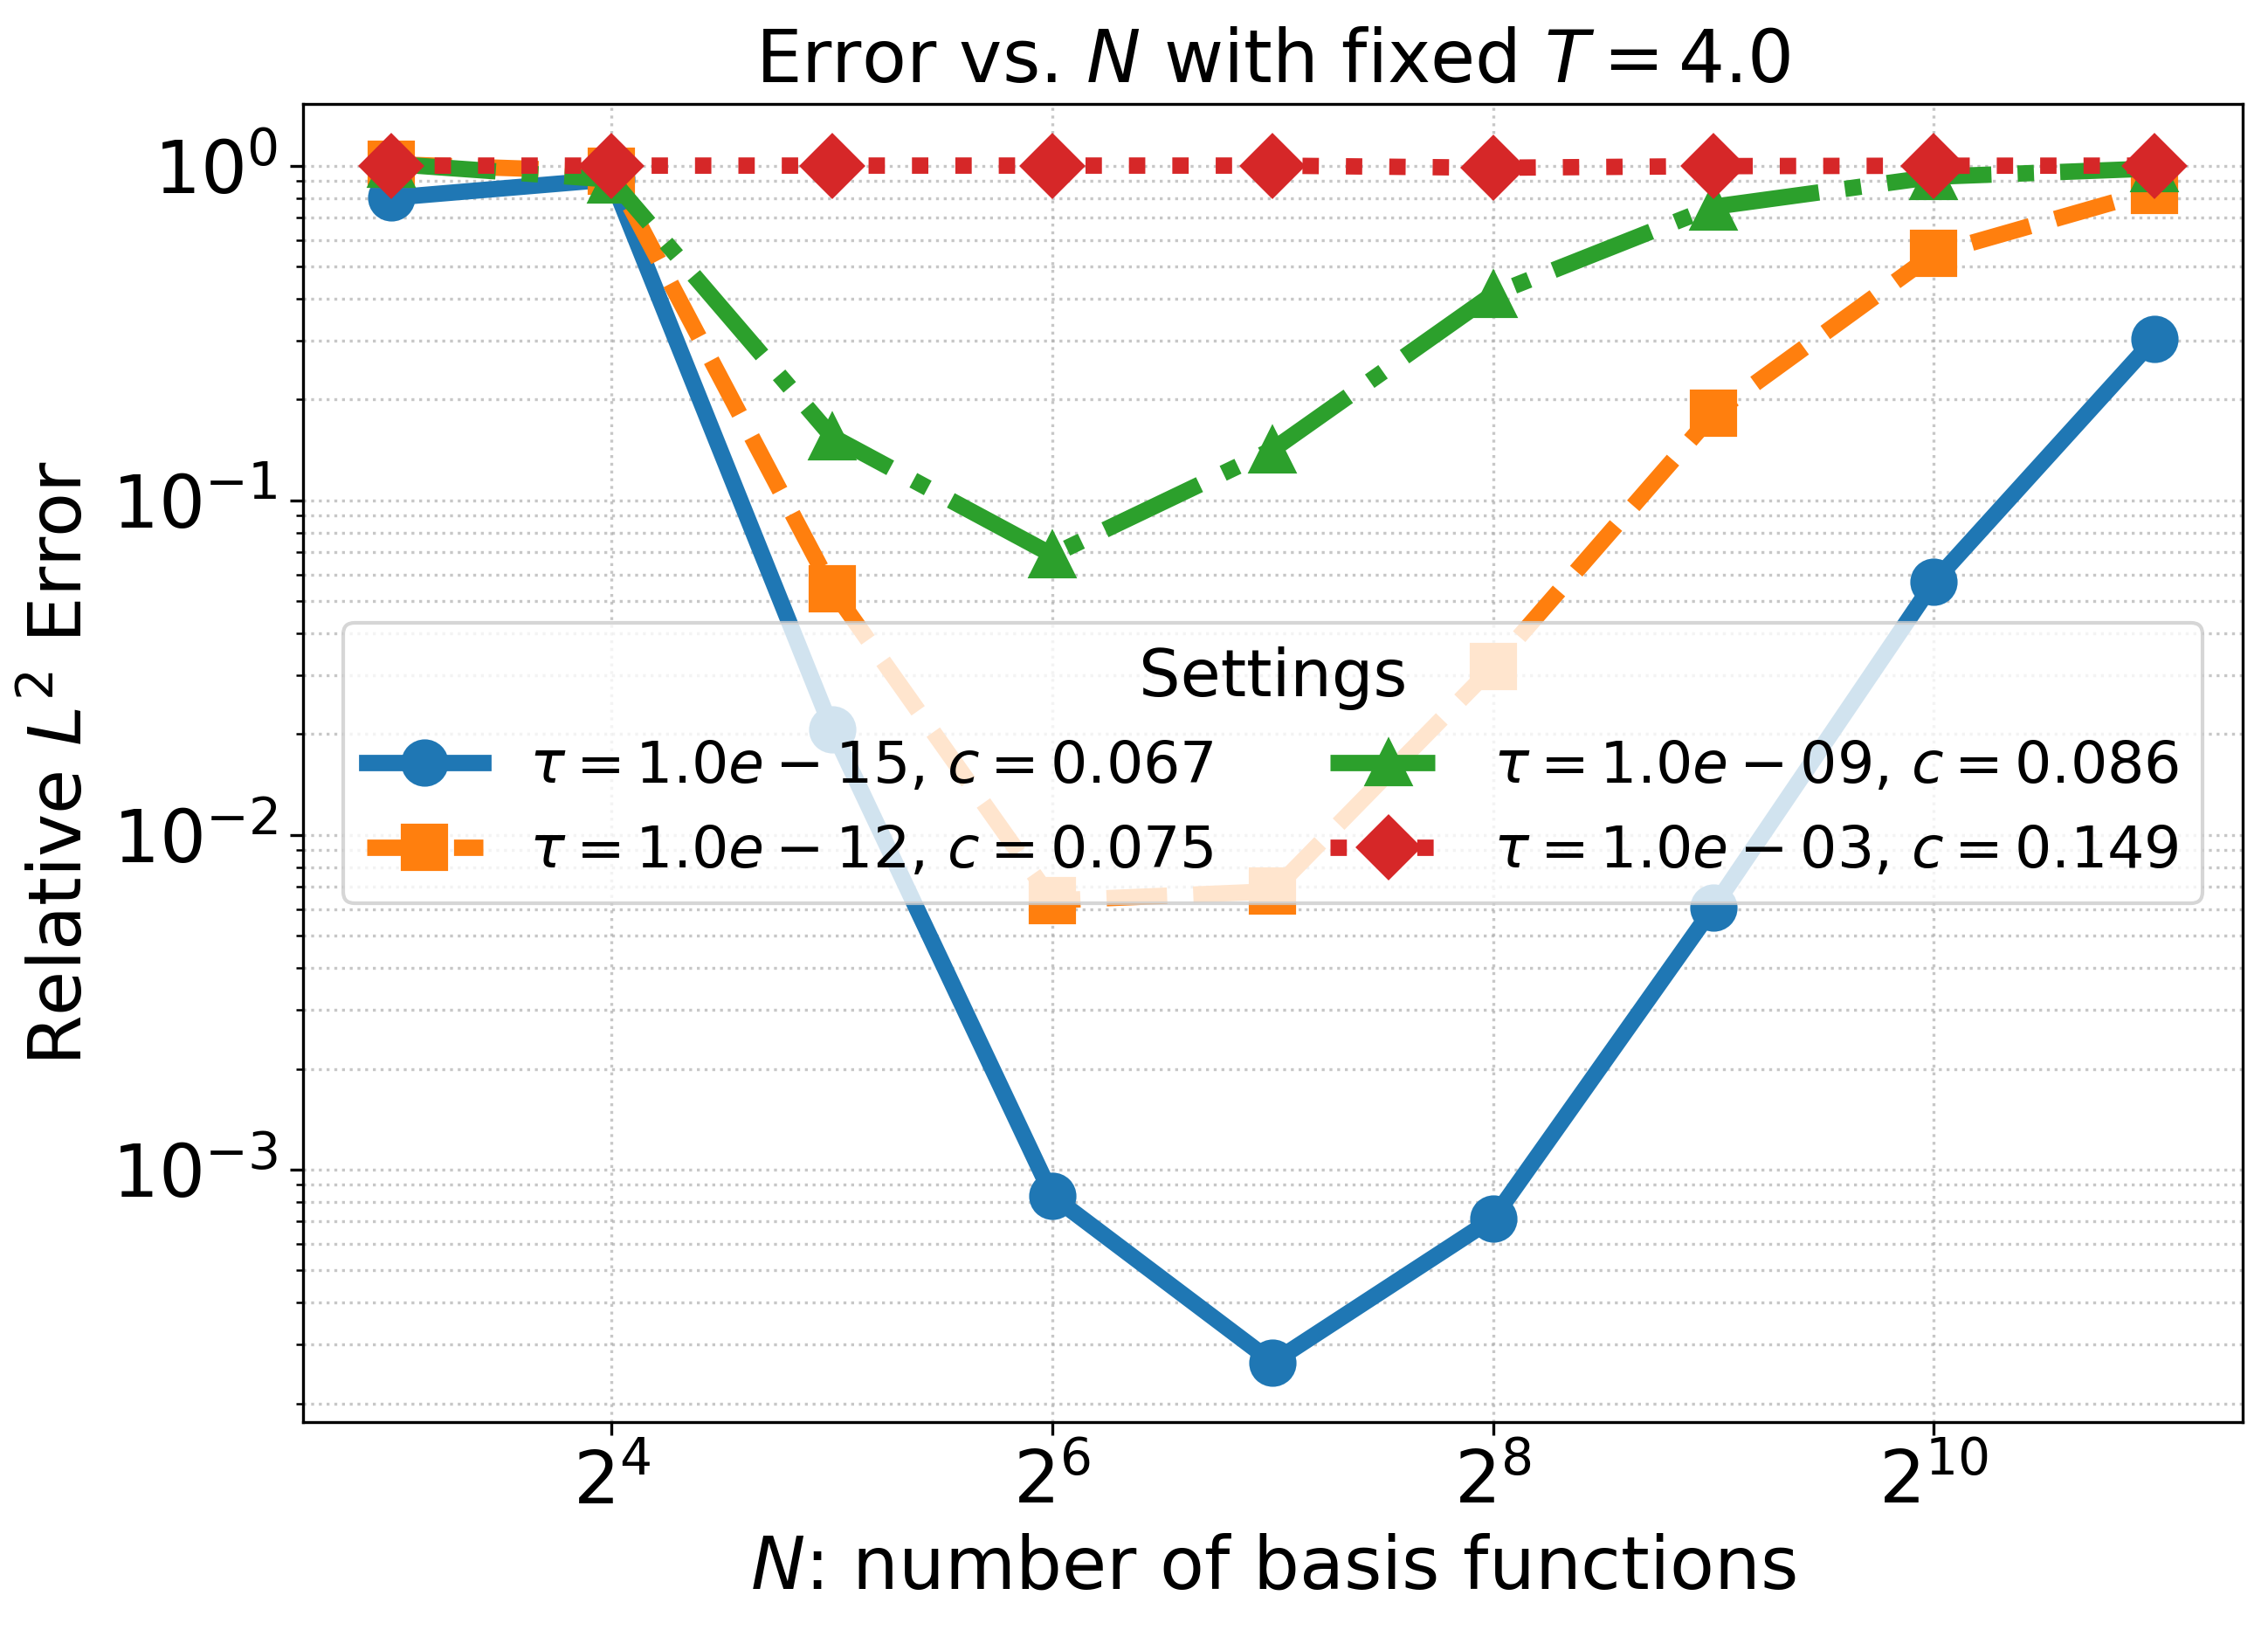

In [23]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 3.5,
    "lines.markersize": 16,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})


# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=4.5,
        markersize=12,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=20)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig11_reactiondiffusion.png')
#plt.show()

In [24]:
# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048], dtype=int)

# Fix T and vary tau
T_fixed = 6.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Cs_used = {}  # tau -> c actually used (for logging)


print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau)
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        rel_l2_err,_,_ = run_rbf_solver(N, T_cent = T_fixed, c_shape=float(c_val), tau=float(tau))
        
        errs.append(float(rel_l2_err))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Cs_used[float(tau)] = float(c_val)

Fixed T = 6.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


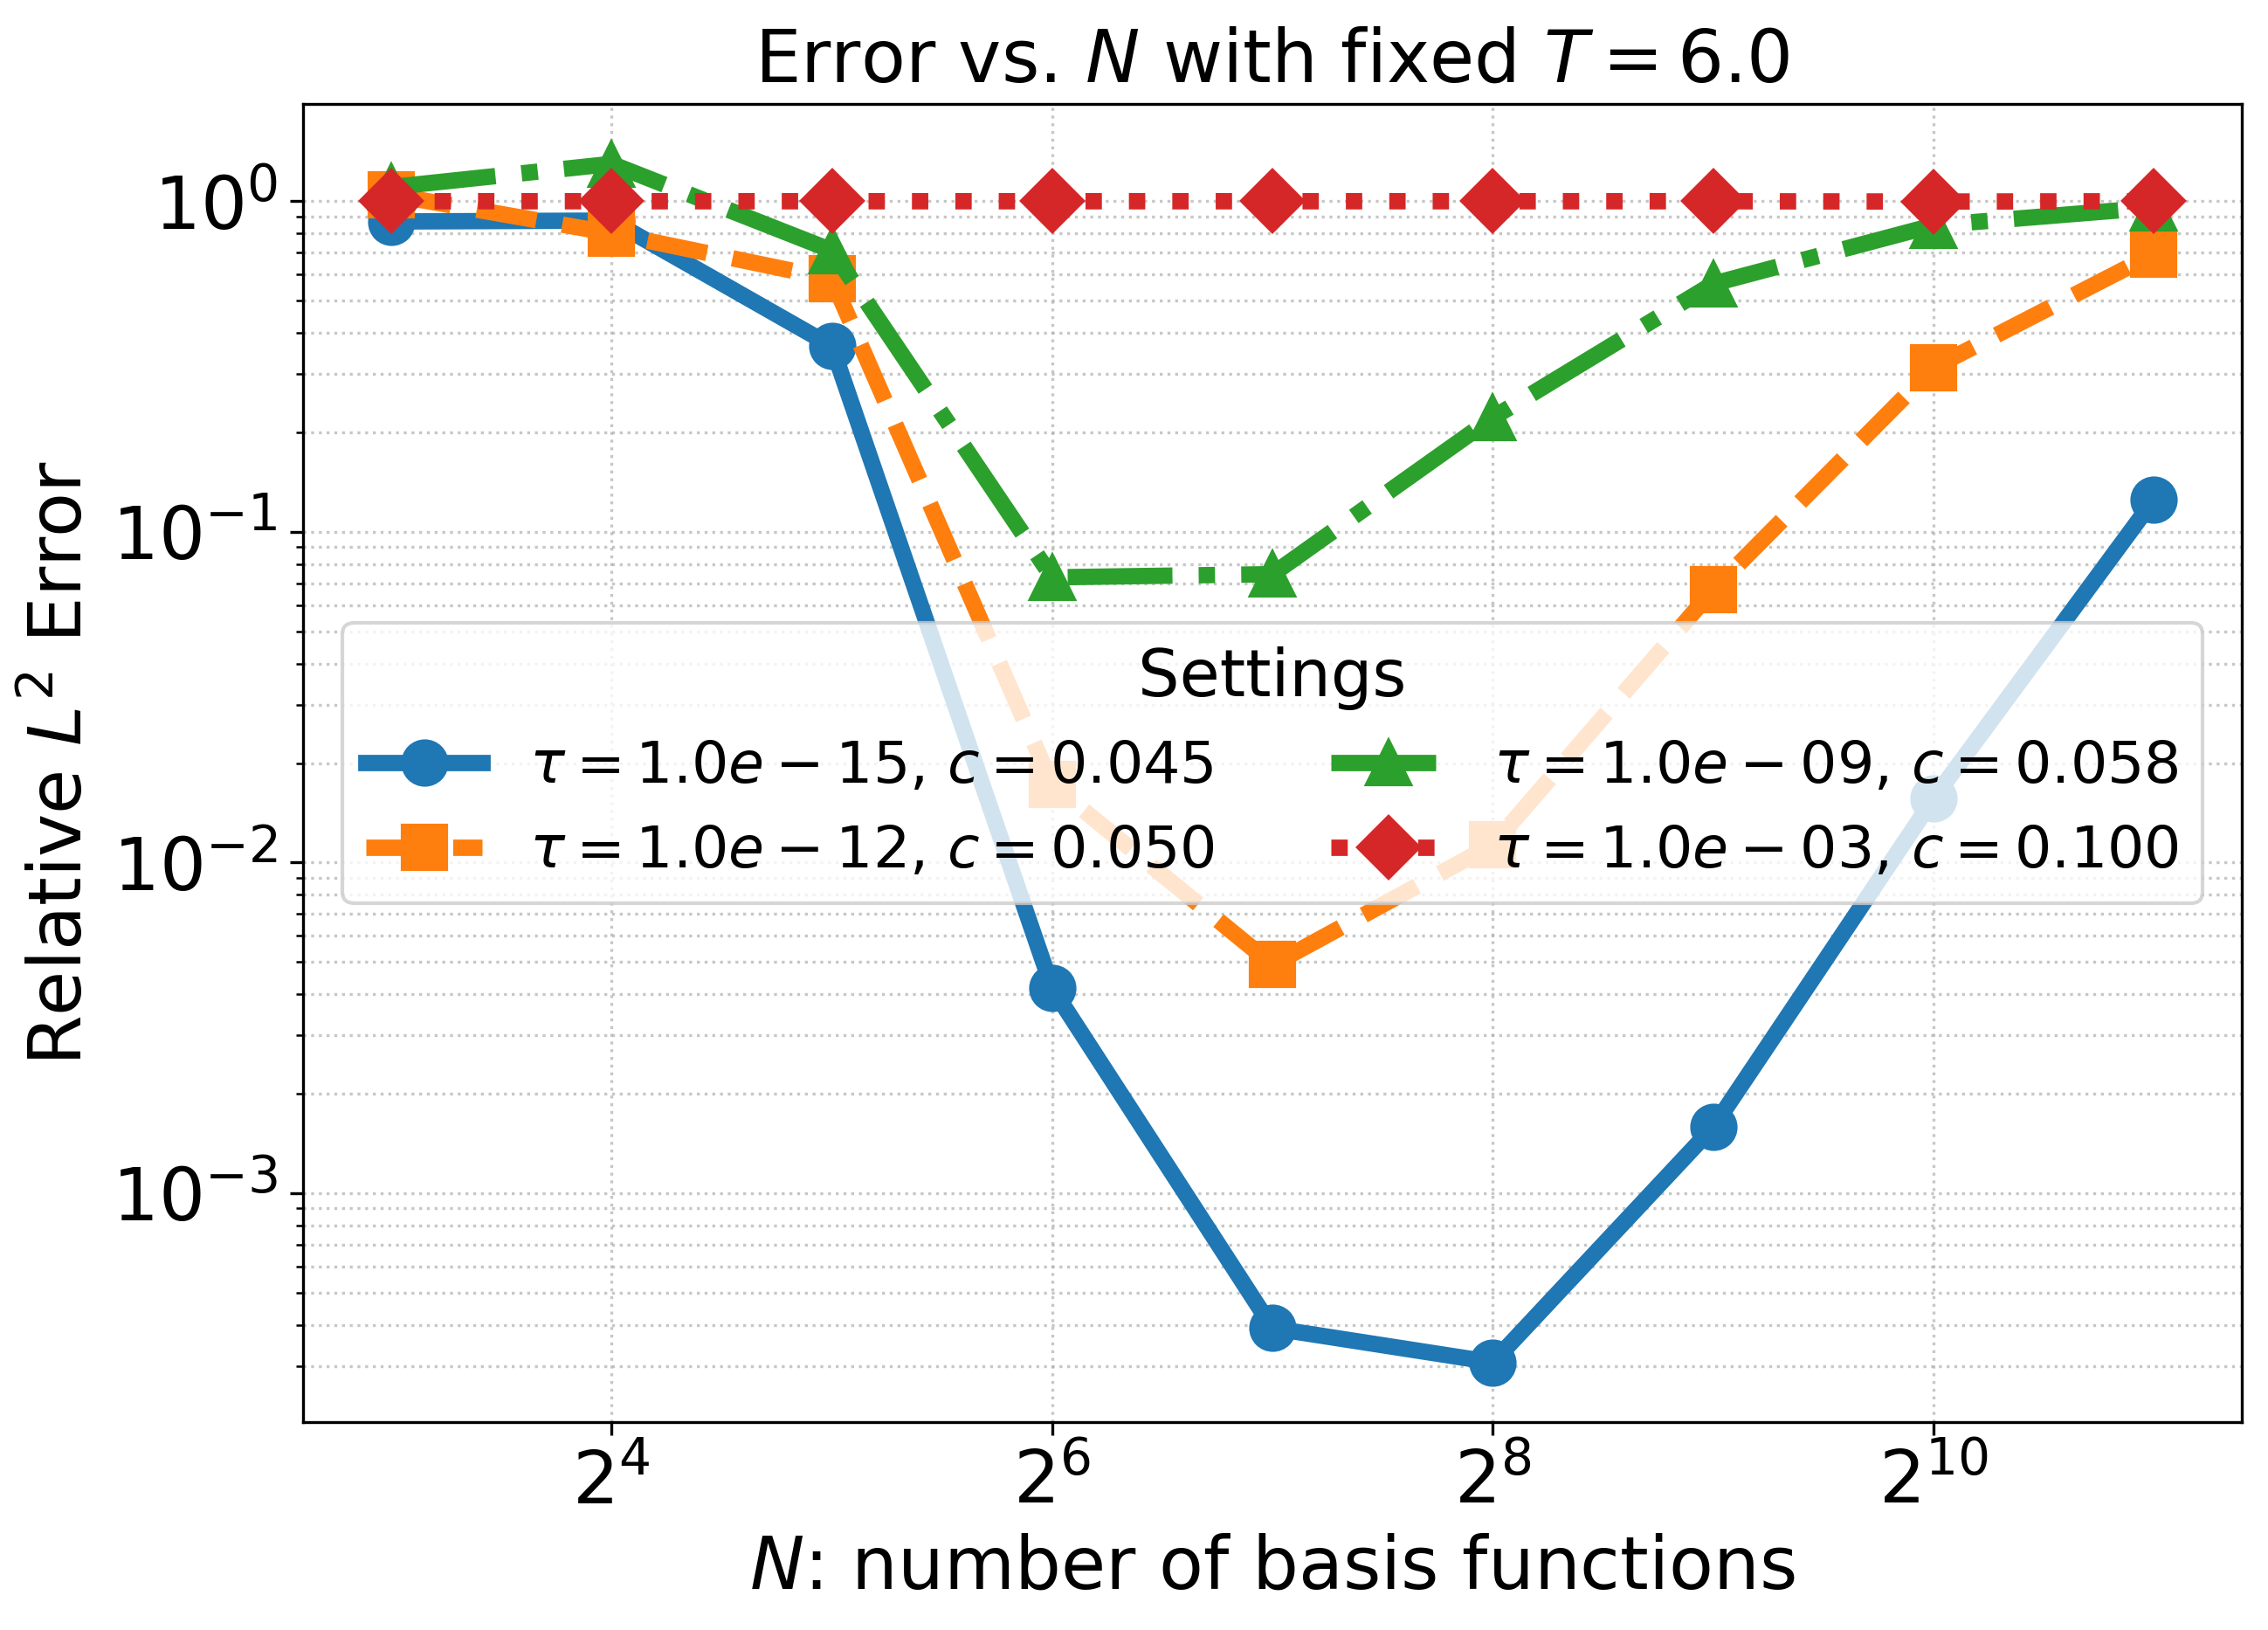

In [25]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})

# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=20)
plt.ylabel(r"Relative $L^2$ Error", fontsize=20)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=20)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig12_reactiondiffusion.png')
#plt.show()